# RETECO Track 1a — Phân tích khám phá dữ liệu
# RETECO Track 1a — Exploratory Data Analysis

**VI** — Báo cáo phân tích bộ dữ liệu **RETECO SemEval-2027 Task 1, Track 1** (Temporal Grounded Retrieval), phục vụ việc thiết kế hệ thống truy hồi cho Sub-track 1a.

**EN** — Analysis of the **RETECO SemEval-2027 Task 1, Track 1** dataset (Temporal Grounded Retrieval), in support of designing a retrieval system for Sub-track 1a.

## Mục tiêu · Objectives

**VI** — Trả lời bốn câu hỏi trước khi đầu tư công sức vào bất kỳ hướng kỹ thuật nào:

1. Dữ liệu có toàn vẹn không, và có giới hạn cứng nào đã tồn tại sẵn không?
2. Truy vấn và tài liệu có đặc điểm gì buộc hệ thống phải xử lý riêng?
3. Tín hiệu nào thật sự tồn tại trong dữ liệu, và tín hiệu nào chỉ tồn tại trên giả định?
4. Một chênh lệch điểm số phải lớn tới đâu mới được coi là thật?

**EN** — Answer four questions before investing effort in any technical direction:

1. Is the data intact, and does any hard ceiling already exist?
2. What properties of the queries and documents force special handling?
3. Which signals actually exist in the data, and which exist only in our assumptions?
4. How large must a score difference be before it counts as real?

**VI** — Mỗi phần kết thúc bằng một **quyết định** kèm ngưỡng cụ thể, không dừng ở việc trình bày con số.
**EN** — Every part ends in a **decision** with an explicit threshold, not merely a number.

## Phạm vi và điều kiện chạy · Scope and requirements

**VI**
- Chỉ dùng CPU. Không tải mô hình, không cần GPU.
- Notebook tự chứa: chỉ cần thư mục `reteco_data`, không phụ thuộc mã nguồn khác của dự án.
- Corpus được đọc theo dòng ở những phần cho phép, nên domain lớn nhất (`history`, 1,28 GB) không nằm hết trong bộ nhớ.
- Bảy phần độc lập nhau, chạy theo nhu cầu.

**EN**
- CPU only. No model downloads, no GPU.
- Self-contained: needs only the `reteco_data` directory, no other project code.
- Corpora are streamed line by line where possible, so the largest domain (`history`, 1.28 GB) never sits in memory at once.
- The seven parts are independent; run what you need.

| Phần · Part | Nội dung · Contents | Thời gian · Runtime |
| --- | --- | --- |
| A | Toàn vẹn dữ liệu và thành phần corpus · Data integrity and corpus composition | nhanh · fast |
| B | Cấu trúc truy vấn · Query structure | nhanh · fast |
| C | Tài liệu gold và quan hệ với truy vấn · Gold documents and their relation to queries | trung bình · medium |
| D | Trần khả năng truy hồi và phép thử dạng truy vấn · Retrievability ceiling and query-form ablation | chậm · slow |
| E | Độ tin cậy thống kê · Statistical reliability | nhanh · fast |
| F | Cấu trúc mã định danh tài liệu · Document identifier structure | trung bình · medium |
| G | Tổng kết quyết định · Decision summary | — |


## Thuật ngữ · Glossary

**VI** — Bốn thuật ngữ xuất hiện xuyên suốt báo cáo, đều là từ vựng chuẩn của ngành truy hồi thông tin chứ không phải do bộ dữ liệu này đặt ra.

**EN** — Four terms used throughout. All are standard information-retrieval vocabulary, not inventions of this dataset.

| Thuật ngữ · Term | Giải thích · Meaning |
| --- | --- |
| **gold** | Không liên quan tới kim loại vàng — rút gọn của *gold standard*, nghĩa là đáp án đúng do con người xác định, dùng làm mốc chấm điểm. Trong dữ liệu, trường `gold_ids` liệt kê các tài liệu thật sự trả lời được truy vấn. · Nothing to do with the metal — short for *gold standard*: the human-assigned correct answer used as the scoring reference. In the data, the `gold_ids` field lists the documents that actually answer a query. |
| **qrels** | Viết tắt của *query relevance judgments*. Cùng thông tin với `gold_ids` nhưng ở định dạng bảng bốn cột chuẩn TREC (`qid 0 docid rel`), là thứ bộ chấm điểm đọc vào. · Short for *query relevance judgments*: the same information as `gold_ids` in the four-column TREC table format (`qid 0 docid rel`) that the scorer reads. |
| **recall@k** | Tỷ lệ tài liệu gold xuất hiện trong `k` kết quả đầu. Đo khả năng *tìm thấy*, không quan tâm thứ tự. · The share of gold documents appearing in the top `k` results. Measures whether they were *found*, regardless of order. |
| **nDCG@10** | Chỉ số chính thức của cuộc thi. Đối chiếu mười kết quả đầu với qrels, thưởng nhiều hơn khi tài liệu gold nằm ở vị trí cao, rồi chuẩn hoá theo trường hợp xếp hạng lý tưởng. · The official competition metric. Compares the top ten results against the qrels, rewarding gold documents at higher ranks, normalised against the ideal ranking. |


## Thiết lập · Setup

**VI** — Ô mã dưới đây tự tìm thư mục dữ liệu, khai báo các hằng số dùng chung và vài hàm tiện ích. Mọi phần sau đều phụ thuộc vào ô này.

**EN** — The cell below locates the data directory, declares shared constants, and defines a few helpers. Every later part depends on it.

In [ ]:
import os, re, json, random, hashlib, statistics as st
from collections import Counter, defaultdict

import numpy as np

CANDIDATE_PATHS = ["/kaggle/working/RETECO-project/reteco_data",
                   "D:/RETECO-project/reteco_data",
                   os.path.expanduser("~/RETECO-project/reteco_data"),
                   "./reteco_data"]
DATA = next((p for p in CANDIDATE_PATHS if os.path.isdir(f"{p}/track1_tempo")), None)
assert DATA, f"reteco_data not found. Tried: {CANDIDATE_PATHS}"
TRACK1 = f"{DATA}/track1_tempo"

ALL_DOMAINS   = sorted(d for d in os.listdir(TRACK1) if os.path.isdir(f"{TRACK1}/{d}"))
SMALL_DOMAINS = ["iota", "law", "quant"]   # small domains, for quick iteration
DOMAINS       = ALL_DOMAINS                # set to SMALL_DOMAINS to run faster
HEAVY_SUBSET  = SMALL_DOMAINS              # scope for Part D, which builds indexes

TOKEN     = re.compile(r"[A-Za-z0-9]+")
YEAR      = re.compile(r"\b(19[5-9]\d|20[0-4]\d)\b")
TAG       = re.compile(r"</?(p|a|code|pre|br|li|ul|ol|blockquote|em|strong|img|div|span)\b", re.I)
ENTITY    = re.compile(r"&(quot|amp|lt|gt|nbsp|#\d+);")
STOPWORDS = set(("the a an of to in is are was were and or for on at by be been it this that as with "
                 "from i you he she they we do does did how what when where why which who can could "
                 "would should if then than there here have has had not no but so my your").split())

def content_terms(text):
    """Meaningful terms of a text: stopwords and very short tokens removed."""
    return {w for w in TOKEN.findall(text.lower()) if w not in STOPWORDS and len(w) > 2}

def norm_hash(text):
    """Hash of the text after normalising whitespace and case."""
    return hashlib.md5(" ".join(text.split()).lower().encode()).digest()

def pct(a, b):
    return f"{a/max(b,1)*100:.1f}%"

def stream_docs(domain):
    """Yield (doc_id, content) without holding the whole corpus in memory."""
    with open(f"{TRACK1}/{domain}/documents.jsonl", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                d = json.loads(line)
                yield d["id"], d["content"]

def load_queries(domain, split="train"):
    with open(f"{TRACK1}/{domain}/examples_{split}.jsonl", encoding="utf-8") as f:
        return [json.loads(l) for l in f if l.strip()]

def split_title(query):
    """Title is everything before the first <p>; the rest is the post body."""
    m = re.search(r"<p>", query)
    return (query[:m.start()], query[m.start():]) if m else (query, "")

print("Data directory:", DATA)
print(f"{len(ALL_DOMAINS)} domains:", ALL_DOMAINS)


Data directory: D:/RETECO-project/reteco_data
13 domains: ['bitcoin', 'cardano', 'economics', 'genealogy', 'history', 'hsm', 'iota', 'law', 'monero', 'politics', 'quant', 'travel', 'workplace']


## Thiết lập biểu đồ · Chart setup

**VI** — Các phần bên dưới đều in bảng số trước rồi mới vẽ biểu đồ: bảng là nguồn tra cứu chính xác, biểu đồ để nhận ra dạng phân bố và giá trị ngoại lai nhanh hơn đọc số. Bảng màu đã được kiểm định về độ tách biệt cho người mù màu; biểu đồ chỉ có một chuỗi dữ liệu luôn dùng một màu duy nhất, không tô đậm nhạt theo độ lớn.

**EN** — Each part prints its table first and plots afterwards: the table is the precise reference, the chart makes distribution shape and outliers faster to see than reading numbers. The palette is validated for colour-vision-deficiency separation; single-series charts use one colour throughout rather than shading by magnitude.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Validated categorical palette: clears the CVD separation threshold on every
# adjacent pair. At most four slots are used anywhere in this notebook.
PALETTE   = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK       = "#0b0b0b"    # primary text
INK_MUTED = "#52514e"    # secondary text, axis labels
GRID      = "#e1e0d9"
AXIS      = "#c3c2b7"
SURFACE   = "#fcfcfb"

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "font.size": 9, "axes.titlesize": 10.5, "axes.labelsize": 9,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
})

def new_axes(width=9.0, height=4.2, grid_axis="x"):
    """Chart frame: thin spines, solid hairline grid pushed behind the marks."""
    fig, ax = plt.subplots(figsize=(width, height))
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS); ax.spines[side].set_linewidth(0.8)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5, length=3, width=0.8)
    if grid_axis:
        ax.grid(True, axis=grid_axis, color=GRID, linewidth=0.8, linestyle="-")
    ax.set_axisbelow(True)
    return fig, ax

def set_title(ax, title, subtitle=None):
    """Title on top, subtitle between the title and the plotting area."""
    ax.set_title(title, loc="left", color=INK, pad=24 if subtitle else 10,
                 fontweight="medium")
    if subtitle:
        ax.annotate(subtitle, xy=(0, 1), xycoords="axes fraction", xytext=(0, 7),
                    textcoords="offset points", color=INK_MUTED, fontsize=8.5,
                    va="bottom", ha="left")

print("Chart style configured.")


Chart style configured.


# Phần A — Toàn vẹn dữ liệu và thành phần corpus
# Part A — Data integrity and corpus composition

## A1. Kiểm tra toàn vẹn · Integrity check

**VI — Mục đích.** Xác lập rằng dữ liệu không có khiếm khuyết làm sai lệch mọi phân tích phía sau.

**EN — Purpose.** Establish that the data has no defect that would distort every later analysis.

| Cột · Column | Ý nghĩa · Meaning | Hệ quả nếu khác 0 · Consequence if non-zero |
| --- | --- | --- |
| `gold missing` | Tài liệu là đáp án nhưng không có trong corpus · A gold document absent from the corpus | Không thể truy hồi; recall tối đa bị chặn dưới 100% · Unreachable; maximum recall capped below 100% |
| `empty query` | Trường `query` trống · Empty `query` field | Không có đầu vào; truy vấn chắc chắn được 0 điểm · No input; that query scores zero |
| `no gold` | Truy vấn không có đáp án nào · Query with no gold documents | Không chấm điểm được · Cannot be scored |
| `train∩dev` | Cùng mã truy vấn ở cả hai split · Same query id in both splits | Phép kiểm tra giữ lại mất hiệu lực · The held-out check is invalidated |
| `dup queries` | Hai truy vấn nội dung giống hệt · Two identical query texts | Không sai, nhưng tăng phương sai của macro · Not an error, but inflates macro variance |

In [ ]:
print(f"{'domain':<14}{'gold missing':>14}{'empty query':>13}{'no gold':>9}"
      f"{'train∩dev':>11}{'dup queries':>13}")
print("-" * 74)
for domain in DOMAINS:
    corpus_ids = {i for i, _ in stream_docs(domain)}
    train, dev = load_queries(domain, "train"), load_queries(domain, "dev")
    missing  = sum(1 for e in train + dev for g in e["gold_ids"] if g not in corpus_ids)
    empty    = sum(1 for e in train + dev if not e["query"].strip())
    no_gold  = sum(1 for e in train + dev if not e["gold_ids"])
    overlap  = len({e["id"] for e in train} & {e["id"] for e in dev})
    seen     = Counter(norm_hash(e["query"]) for e in train + dev)
    dups     = sum(v - 1 for v in seen.values() if v > 1)
    flag = "   <-- CHECK" if (missing or empty or no_gold or overlap) else ""
    print(f"{domain:<14}{missing:>14}{empty:>13}{no_gold:>9}{overlap:>11}{dups:>13}{flag}")


domain          gold missing  empty query  no gold  train∩dev  dup queries
--------------------------------------------------------------------------
bitcoin                    0            0        0          0            0
cardano                    0            0        0          0            0
economics                  0            0        0          0            0
genealogy                  0            0        0          0            0
history                    0            0        0          0            0
hsm                        0            0        0          0            0
iota                       0            0        0          0            0
law                        0            0        0          0            0
monero                     0            0        0          0            0
politics                   0            0        0          0            0
quant                      0            0        0          0            0
travel                   

### Quyết định · Decision

**VI**
- **Bốn cột đầu đều bằng 0** → dữ liệu toàn vẹn, các phân tích sau đọc được nguyên giá trị.
- **`gold missing` khác 0** → ghi lại con số này và trừ vào mọi phép tính recall về sau.
- **`train∩dev` khác 0** → dừng lại, không dùng dev làm tập kiểm tra giữ lại cho tới khi xử lý xong.
- **`dup queries` khác 0** → không cần hành động, nhưng ghi nhận khi đọc phần E.

**EN**
- **All four first columns zero** → the data is intact; later analyses can be read at face value.
- **Non-zero `gold missing`** → record it and subtract it from every recall figure that follows.
- **Non-zero `train∩dev`** → stop; do not use dev as a held-out set until this is resolved.
- **Non-zero `dup queries`** → no action needed, but keep it in mind when reading Part E.

## A2. Thành phần corpus · Corpus composition

**VI — Mục đích.** Độ dài tài liệu quyết định ngưỡng cắt ngắn và việc có cần chia đoạn hay không. Tỷ lệ trùng lặp và rác quyết định có đáng thêm một bước làm sạch vào pipeline hay không.

**EN — Purpose.** Document length decides the truncation threshold and whether chunking is needed. Duplicate and junk rates decide whether a cleaning step earns its place in the pipeline.

**VI — Đo gì.** Phân vị độ dài theo từ, tỷ lệ tài liệu quá ngắn, tỷ lệ trùng lặp tuyệt đối (băm nội dung đã chuẩn hoá), tỷ lệ khớp các mẫu rác thường gặp của dữ liệu thu thập từ web, và tỷ lệ tài liệu chứa thẻ HTML.

**EN — Measured.** Word-count percentiles, share of very short documents, exact-duplicate rate (hash of normalised content), share matching common web-scrape junk patterns, and share containing HTML markup.

In [ ]:
JUNK_PATTERNS = [
    ("load error",  re.compile(r"there was an error while loading", re.I)),
    ("needs js",    re.compile(r"(enable javascript|javascript is (required|disabled))", re.I)),
    ("404 / gone",  re.compile(r"(404 not found|page not found|no longer available)", re.I)),
    ("login wall",  re.compile(r"(sign in to continue|please log ?in to)", re.I)),
    ("cookie bar",  re.compile(r"(we use cookies|accept all cookies)", re.I)),
    ("spam advert", re.compile(r"(herbalist|whatsapp|testimony about|contact him via)", re.I)),
]

LENGTH_STATS = {}

print(f"{'domain':<14}{'docs':>10}{'median':>9}{'p90':>8}{'p99':>9}{'max':>10}"
      f"{'<20w':>7}{'dup':>8}{'junk':>7}{'html':>7}")
print("-" * 93)
for domain in DOMAINS:
    n = short = junk = html = 0
    lengths, seen = [], set()
    for _id, text in stream_docs(domain):
        n += 1
        words = len(text.split()); lengths.append(words)
        if words < 20: short += 1
        seen.add(norm_hash(text))
        if any(p.search(text[:600]) for _, p in JUNK_PATTERNS): junk += 1
        if TAG.search(text[:2000]): html += 1
    lengths.sort()
    LENGTH_STATS[domain] = (lengths[n // 2], lengths[int(.9 * n)], lengths[int(.99 * n)])
    print(f"{domain:<14}{n:>10,}{lengths[n//2]:>9,}{lengths[int(.9*n)]:>8,}"
          f"{lengths[int(.99*n)]:>9,}{lengths[-1]:>10,}"
          f"{pct(short,n):>7}{pct(n-len(seen),n):>8}{pct(junk,n):>7}{pct(html,n):>7}")


domain              docs   median     p90      p99       max   <20w     dup   junk   html
---------------------------------------------------------------------------------------------
bitcoin          153,291      134     294    1,949 1,513,968   1.1%   50.0%   0.2%   0.0%
cardano           87,201      129     245    2,734   992,360   1.2%   45.5%   0.1%   0.0%
economics         93,756      150     414    2,251   272,386   0.8%   20.3%   0.1%   0.0%
genealogy        156,228      152     391    2,204   839,850   0.6%   12.9%   0.0%   0.0%
history          356,493      104     615    7,264    43,745   2.0%   43.8%   0.2%   0.0%
hsm              213,818      163     414    2,356   391,219   0.5%   20.7%   0.0%   0.0%
iota              10,372      152     509   28,271   272,386   1.3%    6.7%   0.4%   0.0%
law               43,288      145     409    2,558   272,386   1.2%   16.6%   0.2%   0.0%
monero            85,093      148     373    4,631   823,419   1.6%   36.6%   0.2%   0.0%
politi

### Quyết định · Decision

| Quan sát · Observation | Ngưỡng · Threshold | Hành động · Action |
| --- | --- | --- |
| Tỷ lệ `dup` · duplicate rate | ≥ 2% | Gộp tài liệu trùng trước khi đánh index. nDCG@10 chỉ có mười vị trí; hai bản sao chiếm hai vị trí là mất một cơ hội. · Merge duplicates before indexing. nDCG@10 has only ten slots; two copies occupying two of them waste one. |
| Tỷ lệ `dup` | < 2% | Bỏ qua · Ignore |
| Tỷ lệ `junk` | ≥ 2% | Thêm bước lọc theo mẫu nội dung · Add a content-pattern filter before indexing |
| Tỷ lệ `junk` | < 2% | Không đáng làm bước riêng · Not worth a dedicated step |
| `p99` ≫ `median` | — | Đuôi phân bố nặng; đối chiếu với phần C3 trước khi quyết định chia đoạn · Heavy tail; cross-check with Part C3 before deciding on chunking |
| Tỷ lệ `html` | — | Ghi lại; phần B1 đối chiếu trực tiếp với phía truy vấn · Record it; Part B1 contrasts it against the queries |

**VI** — Nếu quyết định lọc rác, bắt buộc kiểm tra rằng **không tài liệu gold nào bị lọc nhầm**.
**EN** — If you filter junk, you must verify that **no gold document is removed**.

### Biểu đồ · Chart — phân bố độ dài tài liệu · document length distribution

**VI** — Thang ngang là thang log, vì khoảng cách giữa trung vị và giá trị lớn nhất lên tới bốn bậc độ lớn. Mỗi domain một dòng: chấm là trung vị, đoạn kéo dài tới phân vị 99. Phần nằm bên phải đường đứt là phần bị cắt bỏ nếu dùng ngưỡng token đó.

**EN** — The x-axis is logarithmic because median and maximum span four orders of magnitude. One row per domain: the dot is the median, the segment extends to the 99th percentile. Anything right of the dashed line is discarded at that token budget.

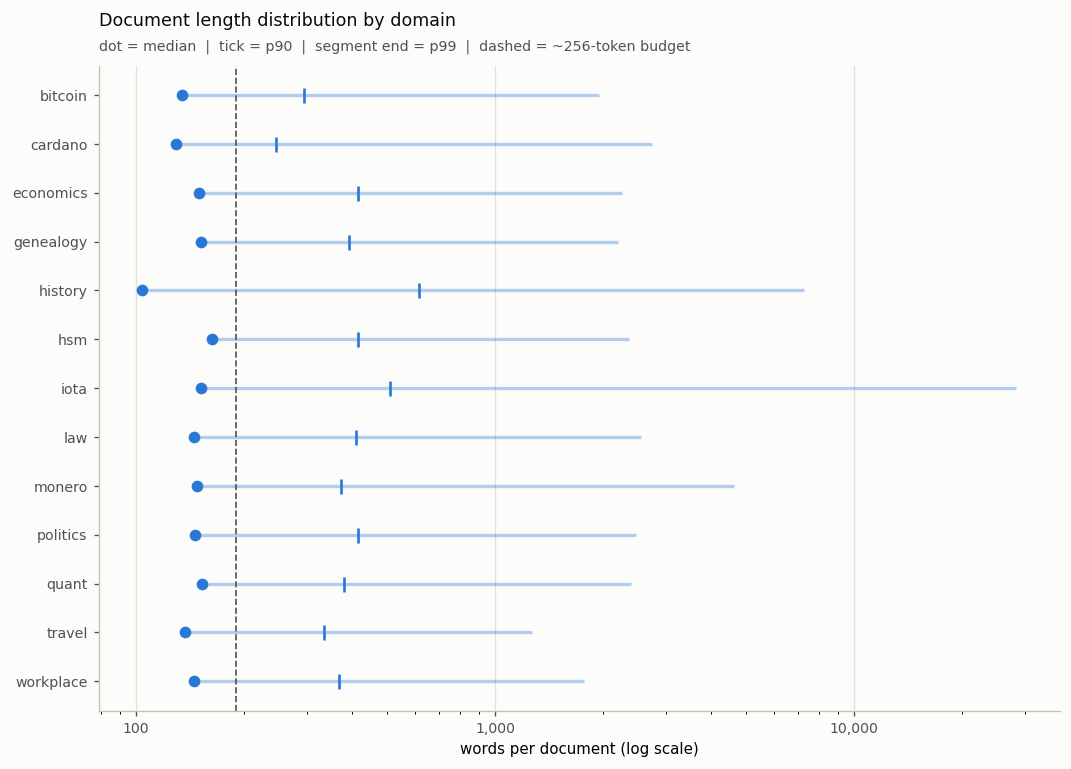

In [ ]:
names = list(LENGTH_STATS)
fig, ax = new_axes(height=0.36 * len(names) + 1.8, grid_axis="x")
y      = np.arange(len(names))
median = [LENGTH_STATS[d][0] for d in names]
p90    = [LENGTH_STATS[d][1] for d in names]
p99    = [LENGTH_STATS[d][2] for d in names]

ax.hlines(y, median, p99, color=PALETTE[0], linewidth=2, alpha=0.35)
ax.plot(p90, y, "|", color=PALETTE[0], markersize=9, markeredgewidth=1.6)
ax.plot(median, y, "o", color=PALETTE[0], markersize=6)
ax.axvline(190, color=INK_MUTED, linewidth=1, linestyle="--")

ax.set_yticks(y); ax.set_yticklabels(names); ax.invert_yaxis()
ax.set_xscale("log")
ticks = [v for v in (100, 1_000, 10_000, 100_000, 1_000_000) if v <= max(p99) * 2]
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_xlabel("words per document (log scale)")
set_title(ax, "Document length distribution by domain",
          "dot = median  |  tick = p90  |  segment end = p99  |  dashed = ~256-token budget")
plt.tight_layout(); plt.show()


## A3. Trùng lặp corpus giữa các domain · Cross-domain corpus overlap

**VI — Mục đích.** Tài liệu mô tả bộ dữ liệu khẳng định mỗi domain là một corpus độc lập. Cần kiểm chứng, vì hai hệ quả: một kỹ thuật tinh chỉnh trên domain này có thể tỏ ra hiệu quả ở domain khác vì lý do không liên quan đến năng lực thật; và trung bình macro sẽ kém độc lập hơn vẻ ngoài, làm hẹp khoảng tin cậy một cách giả tạo.

**EN — Purpose.** The dataset documentation states each domain is a self-contained corpus. Worth verifying, for two reasons: a technique tuned on one domain may appear to transfer for reasons unrelated to real capability; and the macro average would be less independent than it looks, artificially narrowing confidence intervals.

**VI — Chi phí.** Ô này băm toàn bộ tài liệu của các domain được chọn, nên mặc định chỉ chạy trên ba domain nhỏ.
**EN — Cost.** This hashes every document of the selected domains, so it defaults to the three small ones.

In [ ]:
COMPARE = SMALL_DOMAINS     # set to DOMAINS for the full picture

signatures = {}
for domain in COMPARE:
    signatures[domain] = {norm_hash(t) for _, t in stream_docs(domain)}
    print(f"  {domain:<14}{len(signatures[domain]):>9,} unique documents")

print()
names = list(signatures)
found = False
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = names[i], names[j]
        shared = len(signatures[a] & signatures[b])
        if shared:
            found = True
            print(f"  {a} ∩ {b}: {shared:,} shared documents "
                  f"({pct(shared, min(len(signatures[a]), len(signatures[b])))} of the smaller corpus)")
if not found:
    print("  No document appears in two corpora -- the domains are disjoint.")


  iota              9,680 unique documents
  law              36,101 unique documents
  quant            25,040 unique documents

  iota ∩ law: 9 shared documents (0.1% of the smaller corpus)
  iota ∩ quant: 18 shared documents (0.2% of the smaller corpus)
  law ∩ quant: 29 shared documents (0.1% of the smaller corpus)


### Quyết định · Decision

**VI** — Không giao nhau → giả định độc lập đứng vững, trung bình macro đọc được như bình thường. Có giao nhau đáng kể → ghi rõ trong báo cáo và thận trọng khi kết luận rằng một kỹ thuật "tổng quát hoá tốt giữa các domain".

**EN** — No overlap → the independence assumption holds and the macro average reads normally. Substantial overlap → state it in the report and be careful about claiming a technique "generalises across domains".

# Phần B — Cấu trúc truy vấn
# Part B — Query structure

## B1. Giải phẫu truy vấn · Query anatomy

**VI — Mục đích.** Truy vấn trong bộ dữ liệu này không phải câu hỏi ngắn gọn mà là nguyên văn bài đăng diễn đàn. Hai đặc điểm ảnh hưởng trực tiếp đến kết quả: **thẻ đánh dấu** — nếu truy vấn chứa thẻ HTML mà tài liệu không chứa, mọi phép so khớp đều bị nhiễu bởi phần không thuộc nội dung; và **tỷ lệ tiêu đề trên thân bài** — tiêu đề là nhu cầu thông tin cô đọng, thân bài là bối cảnh, nên nếu thân bài dài gấp nhiều lần thì truy vấn thực chất bị bối cảnh chi phối.

**EN — Purpose.** Queries here are not short questions but raw forum post bodies. Two properties bear directly on results: **markup** — if queries carry HTML tags that documents never contain, every match is polluted by non-content tokens; and **title-to-body ratio** — the title is the condensed information need while the body is context, so a body many times longer means the query is dominated by context.

In [ ]:
print(f"{'domain':<14}{'queries':>9}{'title w':>9}{'body w':>8}{'ratio':>8}"
      f"{'has tags':>10}{'entities':>10}{'code':>7}")
print("-" * 76)
for domain in DOMAINS:
    queries = load_queries(domain)
    title_len, body_len = [], []
    for e in queries:
        title, body = split_title(e["query"])
        title_len.append(len(title.split())); body_len.append(len(body.split()))
    tags     = sum(1 for e in queries if TAG.search(e["query"]))
    entities = sum(1 for e in queries if ENTITY.search(e["query"]))
    code     = sum(1 for e in queries if re.search(r"<(code|pre)\b", e["query"]))
    mt, mb = st.median(title_len), st.median(body_len)
    print(f"{domain:<14}{len(queries):>9}{mt:>9.0f}{mb:>8.0f}{mb/max(mt,1):>7.1f}x"
          f"{pct(tags,len(queries)):>10}{pct(entities,len(queries)):>10}{code:>7}")


domain          queries  title w  body w   ratio  has tags  entities   code
----------------------------------------------------------------------------
bitcoin              70        9      82    9.1x    100.0%     27.1%     22
cardano              36        9      50    5.6x    100.0%     30.6%      6
economics            58       11     113   10.3x    100.0%     29.3%      3
genealogy            80       10     110   10.5x    100.0%     33.8%      8
history             561       12     135   11.2x    100.0%     46.7%      3
hsm                 105       10     100   10.0x    100.0%     44.8%      0
iota                  7        7      49    7.0x    100.0%      0.0%      0
law                  24       13      93    7.2x    100.0%     50.0%      0
monero               46       11      52    4.8x    100.0%     13.0%      2
politics            105       14     134    9.6x    100.0%     50.5%      2
quant                24        8     153   18.0x    100.0%     20.8%      0
travel     

### Quyết định · Decision

**VI** — Nếu tỷ lệ `has tags` cao trong khi cột `html` ở phần A2 gần bằng 0, có một sự lệch pha có hệ thống giữa hai phía và cần thêm bước làm sạch truy vấn. Cơ chế gây hại:

- **Truy hồi theo từ khoá.** Bộ tách từ `[A-Za-z0-9]+` biến `<code>`, `<pre>`, `<li>` thành các từ `code`, `pre`, `li` — những từ có nghĩa thật trong tiếng Anh, khớp vào tài liệu không liên quan.
- **Truy hồi theo ngữ nghĩa.** Thẻ chiếm chỗ trong ngân sách token của bộ mã hoá và làm lệch vector, trong khi phía tài liệu không có thành phần tương ứng.

Nếu tỷ lệ tiêu đề trên thân bài lớn, cần kiểm chứng xem thân bài đóng góp hay gây nhiễu — phần D2 đo trực tiếp.

**EN** — If `has tags` is high while the `html` column in A2 is near zero, there is a systematic mismatch between the two sides and query cleaning is warranted. The damage mechanism:

- **Lexical retrieval.** The `[A-Za-z0-9]+` tokeniser turns `<code>`, `<pre>`, `<li>` into the terms `code`, `pre`, `li` — real English words that match unrelated documents.
- **Semantic retrieval.** Tags consume the encoder's token budget and shift the embedding, while the document side has no counterpart.

If the title-to-body ratio is large, test whether the body contributes or interferes — Part D2 measures this directly.

## B2. Dấu hiệu thời gian trên bề mặt truy vấn · Surface temporal markers

**VI — Mục đích.** Track 1 được định nghĩa là truy hồi có ràng buộc thời gian. Bước đầu là xác định ràng buộc đó có xuất hiện tường minh trong văn bản truy vấn hay không, và dưới dạng nào. Phần này chỉ đo **sự hiện diện** của dấu hiệu; việc chúng có dùng được hay không do phần C4 trả lời.

**EN — Purpose.** Track 1 is defined as retrieval under temporal constraints. The first step is to establish whether that constraint appears explicitly in the query text, and in what form. This part measures **presence** only; whether those markers are usable is answered in Part C4.

In [ ]:
TEMPORAL_PATTERNS = [
    ("explicit year",   YEAR),
    ("month name",      re.compile(r"\b(january|february|march|april|june|july|august|september|"
                                   r"october|november|december)\b", re.I)),
    ("now / today",     re.compile(r"\b(today|now|currently|at present|nowadays)\b", re.I)),
    ("latest / recent", re.compile(r"\b(latest|newest|most recent|recently|up to date)\b", re.I)),
    ("since / until",   re.compile(r"\b(since|until|till|as of)\b", re.I)),
    ("before / after",  re.compile(r"\b(before|after|prior to)\b", re.I)),
    ("duration",        re.compile(r"\b(how long|duration|lasts?|period of)\b", re.I)),
    ("change / trend",  re.compile(r"\b(changed?|evolved?|growth|trend|over time|history of)\b", re.I)),
]

marker_counts, with_any, total = Counter(), 0, 0
for domain in DOMAINS:
    for e in load_queries(domain):
        total += 1
        hit = False
        for name, pattern in TEMPORAL_PATTERNS:
            if pattern.search(e["query"]):
                marker_counts[name] += 1; hit = True
        with_any += hit

print(f"Train queries: {total}\n")
print(f"{'marker':<20}{'queries':>10}{'share':>9}")
print("-" * 39)
for name, _ in TEMPORAL_PATTERNS:
    print(f"{name:<20}{marker_counts[name]:>10}{pct(marker_counts[name],total):>9}")
print("-" * 39)
print(f"{'ANY marker':<20}{with_any:>10}{pct(with_any,total):>9}")
print(f"{'NO marker':<20}{total-with_any:>10}{pct(total-with_any,total):>9}")


Train queries: 1211

marker                 queries    share
---------------------------------------
explicit year              296    24.4%
month name                 164    13.5%
now / today                233    19.2%
latest / recent             60     5.0%
since / until              234    19.3%
before / after             384    31.7%
duration                   149    12.3%
change / trend             164    13.5%
---------------------------------------
ANY marker                 883    72.9%
NO marker                  328    27.1%


### Biểu đồ · Chart — dấu hiệu thời gian · temporal markers

**VI** — Xếp theo tần suất giảm dần. Biểu đồ cho biết dấu hiệu nào **xuất hiện** nhiều, chưa nói gì về việc chúng có hữu ích hay không.

**EN** — Sorted by frequency. The chart shows which markers **appear** often; it says nothing yet about whether they are useful.

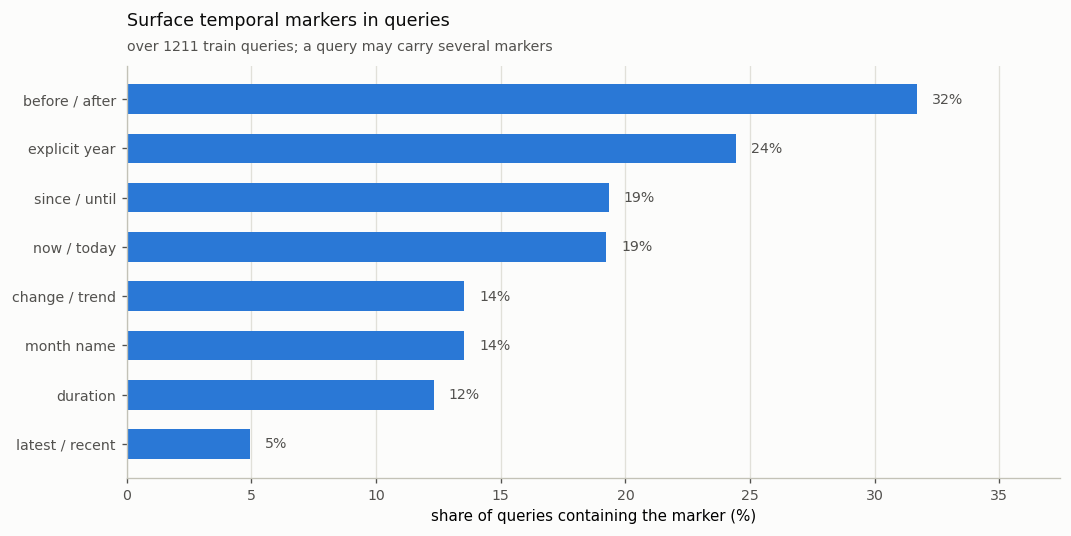

In [ ]:
names  = [n for n, _ in TEMPORAL_PATTERNS]
shares = [marker_counts[n] / total * 100 for n in names]
order  = sorted(range(len(names)), key=lambda i: shares[i])

fig, ax = new_axes(height=0.38 * len(names) + 1.5, grid_axis="x")
y = list(range(len(order)))
ax.barh(y, [shares[i] for i in order], height=0.6, color=PALETTE[0])
for k, i in enumerate(order):
    ax.text(shares[i] + 0.6, k, f"{shares[i]:.0f}%", va="center",
            color=INK_MUTED, fontsize=8.5)

ax.set_yticks(y); ax.set_yticklabels([names[i] for i in order])
ax.set_xlabel("share of queries containing the marker (%)")
ax.set_xlim(0, max(shares) * 1.18)
set_title(ax, "Surface temporal markers in queries",
          f"over {total} train queries; a query may carry several markers")
plt.tight_layout(); plt.show()


### Quyết định · Decision

**VI**
- **Mốc tuyệt đối chiếm ưu thế** (năm, tên tháng) → có cơ sở để cân nhắc module chuẩn hoá ngày tháng. Bắt buộc kiểm chứng tiếp ở phần C4 trước khi xây.
- **Mốc tương đối chiếm ưu thế** (`now / today`, `latest`) → chuẩn hoá ngày tháng không giải quyết được gì; bài toán thật là xác định tính mới và thứ tự của tài liệu.
- **Tỷ lệ `NO marker` cao** → ràng buộc thời gian nằm ẩn trong ngữ nghĩa, mọi cách tiếp cận dựa trên khớp chuỗi đều không chạm tới.

**EN**
- **Absolute markers dominate** (years, month names) → a date-normalisation module has a basis. Verify in Part C4 before building it.
- **Relative markers dominate** (`now / today`, `latest`) → date normalisation solves nothing; the real problem is establishing recency and ordering.
- **High `NO marker` share** → the temporal constraint is implicit in meaning, and no string-matching approach reaches it.

# Phần C — Tài liệu gold
# Part C — Gold documents

## C1. Tập gold và chồng lấn từ vựng · Gold sets and lexical overlap

**VI — Mục đích.** Xác định khoảng cách từ vựng giữa truy vấn và tài liệu đáp án của nó. Đây là chỉ số quyết định trần của mọi phương pháp dựa trên khớp từ khoá.

**EN — Purpose.** Measure the vocabulary gap between a query and its own gold documents. This figure determines the ceiling of any keyword-matching approach.

**VI — Cột quan trọng nhất** là `query terms in gold`: tỷ lệ từ nội dung của truy vấn xuất hiện ở đâu đó trong chính tập gold của nó, sau khi loại hư từ và từ dưới ba ký tự.

**EN — The key column** is `query terms in gold`: the share of a query's content words appearing anywhere in its own gold set, after removing stopwords and very short tokens.

In [ ]:
TERM_OVERLAP = {}

print(f"{'domain':<14}{'queries':>9}{'gold/q':>8}{'gold (w)':>10}{'corpus (w)':>12}"
      f"{'query terms in gold':>21}{'shared gold':>13}")
print("-" * 89)
for domain in DOMAINS:
    queries = load_queries(domain)
    docs = dict(stream_docs(domain))
    gold_counts = [len(e["gold_ids"]) for e in queries]
    gold_len = [len(docs[g].split()) for e in queries for g in e["gold_ids"] if g in docs]
    corpus_len = sorted(len(t.split()) for t in docs.values())
    overlaps = []
    for e in queries:
        q_terms = content_terms(e["query"])
        if not q_terms:
            continue
        pool = set()
        for g in e["gold_ids"]:
            if g in docs:
                pool |= content_terms(docs[g])
        overlaps.append(len(q_terms & pool) / len(q_terms))
    TERM_OVERLAP[domain] = sum(overlaps) / max(len(overlaps), 1) * 100
    shared = sum(1 for v in Counter(g for e in queries for g in e["gold_ids"]).values() if v > 1)
    print(f"{domain:<14}{len(queries):>9}{st.median(gold_counts):>8.0f}{st.median(gold_len):>10.0f}"
          f"{corpus_len[len(corpus_len)//2]:>12}{TERM_OVERLAP[domain]:>20.1f}%{shared:>13}")
    del docs


domain          queries  gold/q  gold (w)  corpus (w)  query terms in gold  shared gold
-----------------------------------------------------------------------------------------
bitcoin              70       3        94         134                28.5%            0
cardano              36       2       260         129                33.5%            0
economics            58       3       277         150                32.9%            0
genealogy            80       2       335         152                31.0%            0
history             561       3       214         104                27.4%            0
hsm                 105       2       734         163                42.6%            0
iota                  7       4       276         152                48.3%            0
law                  24       4       103         145                28.1%            0
monero               46       3        64         148                27.2%            0
politics            105       

### Biểu đồ · Chart — chồng lấn từ vựng · lexical overlap

**VI** — Hai đường đứt là ngưỡng quyết định 30% và 60% nêu ở bảng dưới. Vị trí của các domain so với hai đường này quyết định phương pháp khớp từ khoá còn bao nhiêu dư địa.

**EN** — The dashed lines are the 30% and 60% decision thresholds from the table below. Where each domain falls relative to them determines how much headroom keyword matching still has.

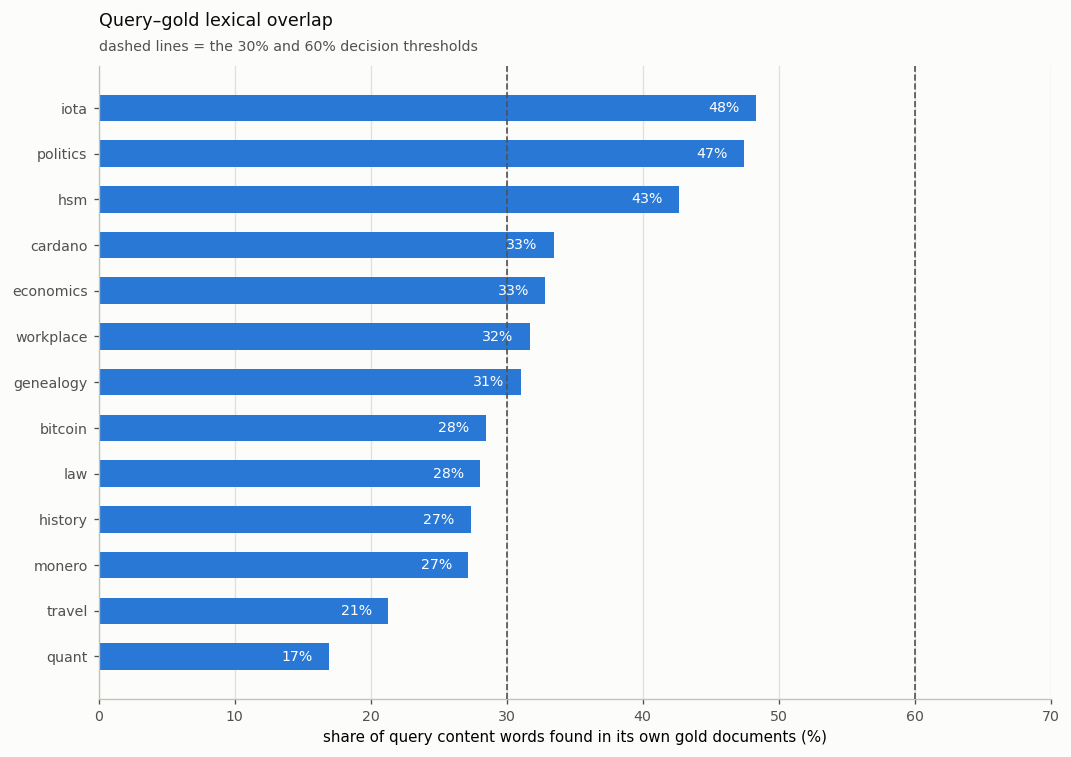

In [ ]:
names  = list(TERM_OVERLAP)
values = [TERM_OVERLAP[d] for d in names]
order  = sorted(range(len(names)), key=lambda i: values[i])

fig, ax = new_axes(height=0.36 * len(names) + 1.7, grid_axis="x")
y = list(range(len(order)))
ax.barh(y, [values[i] for i in order], height=0.58, color=PALETTE[0])
for threshold in (30, 60):
    ax.axvline(threshold, color=INK_MUTED, linewidth=1, linestyle="--", zorder=3)

# Value labels sit inside the bars so they never collide with the threshold lines.
for k, i in enumerate(order):
    ax.text(values[i] - 1.2, k, f"{values[i]:.0f}%", va="center", ha="right",
            color="#ffffff", fontsize=8.5, fontweight="medium")

ax.set_yticks(y); ax.set_yticklabels([names[i] for i in order])
ax.set_xlabel("share of query content words found in its own gold documents (%)")
ax.set_xlim(0, max(max(values) * 1.1, 70))
set_title(ax, "Query–gold lexical overlap",
          "dashed lines = the 30% and 60% decision thresholds")
plt.tight_layout(); plt.show()


### Quyết định · Decision

| Giá trị · Value | Diễn giải · Reading | Hành động · Action |
| --- | --- | --- |
| ≥ 60% | Truy vấn và đáp án dùng chung phần lớn từ vựng · Query and answer share most vocabulary | Khớp từ khoá là nền tảng hợp lý; tinh chỉnh tham số BM25 có ý nghĩa · Keyword matching is a sound base; tuning BM25 parameters is meaningful |
| 30 – 60% | Chồng lấn một phần · Partial overlap | Kết hợp khớp từ khoá với biểu diễn ngữ nghĩa · Combine lexical and semantic representations |
| < 30% | Gần như không dùng chung từ vựng · Almost no shared vocabulary | Khớp từ khoá không có gì để khớp. Ngừng tinh chỉnh tham số; dư địa nằm ở biểu diễn ngữ nghĩa · Lexical matching has nothing to match on. Stop tuning; the headroom is in semantic representation |

**VI** — Con số này nên đưa thẳng vào báo cáo: nó giải thích kết quả của phương pháp cơ sở bằng đặc điểm dữ liệu chứ không bằng phỏng đoán.
**EN** — Put this number in the report: it explains the baseline's result through a property of the data rather than speculation.

## C2. Tài liệu gold bị nhân bản · Duplicated gold documents

**VI — Vấn đề.** Nếu một tài liệu gold có bản sao giống hệt từng byte nằm dưới mã định danh khác, và bản sao đó không được đánh dấu là đáp án, thì hệ thống truy hồi **đúng nội dung cần tìm nhưng vẫn bị chấm 0 điểm** cho tài liệu đó. Đây là mất mát có thật, không phải lỗi của phương pháp truy hồi, và không nhìn thấy được qua chỉ số tổng hợp.

**EN — The problem.** If a gold document has a byte-identical twin under a different identifier, and that twin is not marked as an answer, the system retrieves **exactly the right content and is still scored zero** for it. This is a real loss, not a failure of the retrieval method, and it is invisible in the aggregate metric.

In [ ]:
print(f"{'domain':<14}{'gold':>7}{'with twin':>13}{'decoy copies':>14}")
print("-" * 50)
for domain in DOMAINS:
    queries = load_queries(domain)
    gold = {g for e in queries for g in e["gold_ids"]}
    by_hash, gold_hash = defaultdict(list), {}
    for doc_id, text in stream_docs(domain):
        h = norm_hash(text)
        by_hash[h].append(doc_id)
        if doc_id in gold:
            gold_hash[doc_id] = h
    twinned = [g for g in gold if g in gold_hash and len(by_hash[gold_hash[g]]) > 1]
    copies  = sum(len(by_hash[gold_hash[g]]) - 1 for g in twinned)
    print(f"{domain:<14}{len(gold):>7}{len(twinned):>6} ({pct(len(twinned),len(gold)):>5}){copies:>14}")


domain           gold    with twin  decoy copies
--------------------------------------------------
bitcoin           232    28 (12.1%)            35
cardano            80     1 ( 1.2%)             1
economics         203     4 ( 2.0%)             4
genealogy         233     6 ( 2.6%)             6
history          2546    62 ( 2.4%)           185
hsm               252     0 ( 0.0%)             0
iota               29     2 ( 6.9%)             2
law                77     2 ( 2.6%)             2
monero            122    33 (27.0%)            74
politics          283     0 ( 0.0%)             0
quant              61     9 (14.8%)             9
travel            190    18 ( 9.5%)            18
workplace          73     0 ( 0.0%)             0


### Quyết định · Decision

**VI**
- **Dưới 3%** → ghi nhận, không xử lý.
- **Từ 3% trở lên** → xử lý, vì đây là điểm bị mất không do năng lực truy hồi. Cách làm: dựng bảng ánh xạ từ băm nội dung sang danh sách mã định danh; khi một tài liệu lọt vào nhóm đầu, đưa kèm các bản sao cùng nội dung. Cách này tốn thêm một vị trí trong top 10, nên chỉ áp dụng khi tỷ lệ đủ lớn để bù lại.

Kỹ thuật này dựa hoàn toàn trên **nội dung** tài liệu, không dựa vào cấu trúc mã định danh, nên độc lập với những gì phần F khảo sát.

**EN**
- **Below 3%** → record it, take no action.
- **3% or above** → handle it, since this is score lost for reasons unrelated to retrieval quality. Method: build a map from content hash to identifier list; when a document reaches the top ranks, emit its content-identical siblings alongside it. This costs one slot in the top 10, so apply it only when the rate is large enough to repay that.

This technique works purely from document **content**, not identifier structure, so it is independent of what Part F examines.

## C3. Vị trí bằng chứng bên trong tài liệu gold · Evidence position within gold documents

**VI — Mục đích.** Quyết định giữa hai chiến lược xử lý tài liệu dài: cắt ngắn ở một ngưỡng token cố định, hay chia tài liệu thành nhiều đoạn rồi lấy điểm đoạn cao nhất. Nếu phần nội dung liên quan nằm sâu bên trong tài liệu dài, cắt ngắn sẽ vứt bỏ đúng phần cần thiết. Nếu tài liệu gold vốn ngắn hoặc nội dung dồn về đầu, chia đoạn là công sức bỏ ra không thu lại gì.

**EN — Purpose.** Decide between truncating long documents at a fixed token budget and chunking them with max-pooling. If the relevant content sits deep inside long documents, truncation discards exactly what is needed. If gold documents are short or front-loaded, chunking is wasted effort.

**VI — Lưu ý về phép đo.** Vị trí từ khớp chỉ là ước lượng gián tiếp cho vị trí bằng chứng thật.
**EN — Measurement caveat.** The position of matching terms is only an indirect proxy for where the evidence actually sits.

In [ ]:
WORD_BUDGET = 190   # roughly 256 tokens for a BERT-style encoder
MATCH_POS = {}

print(f"{'domain':<14}{'gold with matches':>19}{'median position':>17}{'past budget':>15}")
print("-" * 68)
for domain in DOMAINS:
    queries = load_queries(domain)
    docs = dict(stream_docs(domain))
    positions, past_budget, total = [], 0, 0
    for e in queries:
        q_terms = content_terms(e["query"])
        for g in e["gold_ids"]:
            if g not in docs:
                continue
            words = docs[g].split(); total += 1
            hits = [i for i, w in enumerate(words) if w.lower().strip(".,()") in q_terms]
            if hits:
                centre = st.median(hits)
                positions.append(centre / max(len(words), 1))
                if centre > WORD_BUDGET:
                    past_budget += 1
    MATCH_POS[domain] = positions
    median_pos = st.median(positions) * 100 if positions else 0
    print(f"{domain:<14}{len(positions):>8}/{total:<10}{median_pos:>16.1f}%"
          f"{past_budget:>8} ({pct(past_budget,total)})")
    del docs


domain          gold with matches  median position    past budget
--------------------------------------------------------------------
bitcoin            230/232                   45.7%       3 (1.3%)
cardano             80/80                    45.9%       7 (8.8%)
economics          203/203                   47.8%      58 (28.6%)
genealogy          231/233                   46.6%      74 (31.8%)
history           2526/2546                  46.6%     221 (8.7%)
hsm                251/252                   46.7%     168 (66.7%)
iota                28/29                    47.5%      11 (37.9%)
law                 76/77                    45.9%       0 (0.0%)
monero             121/122                   45.2%       0 (0.0%)
politics           281/283                   46.5%     192 (67.8%)
quant               60/61                    45.9%       0 (0.0%)
travel             183/190                   47.4%       0 (0.0%)
workplace           73/73                    47.4%      24 (32.9%)


### Biểu đồ · Chart — vị trí bằng chứng · evidence position

**VI** — Gộp toàn bộ tài liệu gold của các domain đang chạy. Trục ngang là vị trí tương đối của các từ khớp theo phần trăm độ dài tài liệu. Phân bố dồn về bên trái nghĩa là nội dung liên quan nằm ở phần đầu và việc cắt ngắn ít gây hại.

**EN** — Pooled over the gold documents of the selected domains. The x-axis is the relative position of matching terms as a percentage of document length. A left-leaning distribution means relevant content sits early and truncation does little harm.

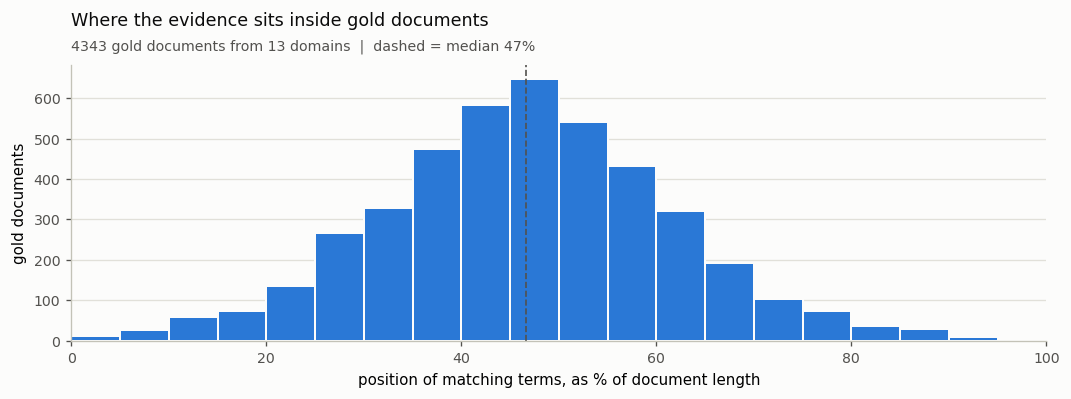

In [ ]:
pooled = [p * 100 for values in MATCH_POS.values() for p in values]

fig, ax = new_axes(height=3.4, grid_axis="y")
ax.hist(pooled, bins=20, range=(0, 100), color=PALETTE[0], edgecolor=SURFACE, linewidth=1.2)
median_pos = float(np.median(pooled)) if pooled else 0
ax.axvline(median_pos, color=INK_MUTED, linewidth=1, linestyle="--")

ax.set_xlabel("position of matching terms, as % of document length")
ax.set_ylabel("gold documents")
ax.set_xlim(0, 100)
set_title(ax, "Where the evidence sits inside gold documents",
          f"{len(pooled)} gold documents from {len(MATCH_POS)} domains  |  "
          f"dashed = median {median_pos:.0f}%")
plt.tight_layout(); plt.show()


### Quyết định · Decision

| `past budget` | Diễn giải · Reading | Hành động · Action |
| --- | --- | --- |
| < 10% | Cắt ngắn gần như không làm mất nội dung gold · Truncation loses almost nothing from gold documents | Không chia đoạn. Kết quả âm có giá trị: nó loại một khối lượng công việc lớn khỏi kế hoạch · No chunking. A valuable negative result: it removes a large item from the plan |
| 10 – 30% | Mất mát trung bình · Moderate loss | Cân nhắc nâng ngưỡng cắt trước, vì rẻ hơn chia đoạn nhiều · Consider raising the truncation limit first; far cheaper than chunking |
| > 30% | Cắt ngắn đang phá hỏng phần đáng kể · Truncation is destroying a substantial share | Chia đoạn và lấy điểm đoạn cao nhất · Chunk and max-pool |

**VI** — Nếu kết quả khác nhau rõ rệt giữa các domain, đối chiếu với cột độ dài tài liệu gold ở C1: chênh lệch thường bám theo độ dài, và có thể xử lý bằng ngưỡng cắt thích ứng thay vì chia đoạn toàn bộ.
**EN** — If domains differ sharply, cross-check against the gold-length column in C1: the split usually tracks length, and an adaptive truncation limit may suffice instead of chunking everything.

## C4. Ăn khớp thời gian · Temporal alignment

**VI — Mục đích.** Phép thử quyết định cho mọi hướng xử lý thời gian dựa trên khớp chuỗi. Phần B2 cho biết có bao nhiêu truy vấn nêu mốc thời gian tường minh, nhưng dấu hiệu chỉ có giá trị nếu nó **ăn khớp** với phía tài liệu. Nếu một truy vấn nêu năm 2017 mà không tài liệu gold nào của nó nhắc tới 2017, việc trích xuất và khớp năm không những vô dụng mà còn gây hại: nó ưu tiên những tài liệu chỉ tình cờ chứa con số đó.

**EN — Purpose.** The decisive test for any string-matching approach to time. Part B2 counts queries carrying explicit temporal markers, but a marker is only useful if it **aligns** with the document side. If a query names 2017 and none of its gold documents mention 2017, extracting and matching years is not merely useless but harmful: it promotes documents that merely happen to contain that number.

In [ ]:
print(f"{'domain':<14}{'docs with year':>16}{'queries w/ year':>17}"
      f"{'year also in gold':>19}{'gold year span':>16}")
print("-" * 82)
for domain in DOMAINS:
    docs = dict(stream_docs(domain))
    queries = load_queries(domain)
    dated = sum(1 for t in docs.values() if YEAR.search(t))
    with_year = [e for e in queries if YEAR.search(e["query"])]
    aligned = 0
    for e in with_year:
        query_years = set(YEAR.findall(e["query"]))
        gold_years = set()
        for g in e["gold_ids"]:
            if g in docs:
                gold_years |= set(YEAR.findall(docs[g]))
        if query_years & gold_years:
            aligned += 1
    spans = []
    for e in queries:
        years = {int(y) for g in e["gold_ids"] if g in docs for y in YEAR.findall(docs[g])}
        if len(years) > 1:
            spans.append(max(years) - min(years))
    print(f"{domain:<14}{pct(dated,len(docs)):>16}{len(with_year):>10}/{len(queries):<6}"
          f"{aligned:>13}/{len(with_year):<5}"
          f"{st.median(spans) if spans else 0:>12.0f} yr")
    del docs


domain          docs with year  queries w/ year  year also in gold  gold year span
----------------------------------------------------------------------------------
bitcoin                  25.6%        15/70                3/15              4 yr
cardano                  29.9%         2/36                0/2              12 yr
economics                39.2%        27/58               16/27             35 yr
genealogy                31.5%        15/80                1/15             34 yr
history                  25.5%       105/561              29/105            29 yr
hsm                      24.1%        11/105               4/11             51 yr
iota                     22.3%         0/7                 0/0               6 yr
law                      32.6%         7/24                0/7              30 yr
monero                   22.3%        16/46                3/16              3 yr
politics                 45.5%        68/105              45/68             36 yr
quant         

### Quyết định · Decision — phần này có thể huỷ cả một hạng mục · this can cancel a roadmap item

| `year also in gold` | Kết luận · Conclusion | Hành động · Action |
| --- | --- | --- |
| Tỷ lệ cao · High | Mốc thời gian trong truy vấn ăn khớp với đáp án · Query years align with the answers | Module trích xuất và chuẩn hoá ngày tháng có cơ sở; xây và đo · A date extraction and normalisation module has a basis; build and measure it |
| Gần bằng 0 · Near zero | Mốc thời gian **không** xuất hiện ở đáp án · Query years do **not** appear in the answers | Khớp năm theo từ khoá vô dụng và có khả năng gây hại. Không xây module ngày tháng · Lexical year matching is useless and likely harmful. Do not build the date module |

**VI** — Cột `gold year span` bổ sung bằng chứng: nếu các năm được nhắc tới trong một tập gold trải rộng hàng chục năm, tập đáp án không tụ quanh một mốc thời gian duy nhất, và giả định "truy vấn hỏi về một thời điểm, đáp án nằm ở thời điểm đó" không đúng với dữ liệu này. Khi cả hai chỉ số đều bất lợi, kết luận là ràng buộc thời gian phải được xử lý bằng **suy luận ngữ nghĩa**, không bằng phân tích cú pháp ngày tháng.

**EN** — The `gold year span` column adds evidence: if the years mentioned across one gold set span decades, the answers do not cluster on a single point in time, and the assumption "the query asks about a moment, the answer lives at that moment" does not hold here. When both figures are unfavourable, the conclusion is that the temporal constraint must be handled by **semantic reasoning**, not date parsing.

# Phần D — Trần khả năng truy hồi và phép thử dạng truy vấn
# Part D — Retrievability ceiling and query-form ablation

**VI** — Hai phần dưới cần một bộ truy hồi để đo. Notebook dùng bản BM25 tự chứa khai báo ngay bên dưới, để không phụ thuộc mã nguồn khác của dự án.

**EN** — The two parts below need a retriever. The notebook uses the self-contained BM25 declared below, so it depends on no other project code.

**VI — Về bản BM25 này.** Công thức Okapi BM25 tiêu chuẩn với `k1=0.9`, `b=0.4`, hàm IDF không âm. Điểm của từng cặp (tài liệu, từ) được tính sẵn vào chỉ mục ngược dạng thưa, nên mỗi truy vấn chỉ chạm vào danh sách tài liệu của chính các từ trong nó. Cách này cần thiết để chạy được trên domain lớn: nếu duyệt toàn bộ corpus cho mỗi truy vấn thì các domain hàng trăm nghìn tài liệu sẽ không khả thi.

**EN — About this BM25.** Standard Okapi BM25 with `k1=0.9`, `b=0.4`, non-negative IDF. The per-(document, term) scores are precomputed into a sparse inverted index, so a query only touches the posting lists of its own terms. This is necessary to run on the larger domains: scanning the whole corpus per query would be infeasible at hundreds of thousands of documents.

In [ ]:
from array import array
from scipy import sparse

class BM25:
    """BM25 over a sparse inverted index. For analysis within this notebook."""

    def __init__(self, doc_ids, contents, k1=0.9, b=0.4):
        self.doc_ids = list(doc_ids)
        self.n_docs  = len(self.doc_ids)

        vocab = {}
        indptr, indices, data = array("q", [0]), array("i"), array("f")
        doc_len = np.zeros(self.n_docs, dtype=np.float32)

        for i, text in enumerate(contents):
            tokens = TOKEN.findall((text or "").lower())
            doc_len[i] = len(tokens)
            counts = {}
            for t in tokens:
                counts[t] = counts.get(t, 0) + 1
            for term, freq in counts.items():
                j = vocab.get(term)
                if j is None:
                    j = len(vocab); vocab[term] = j
                indices.append(j); data.append(freq)
            indptr.append(len(indices))

        n_terms = max(len(vocab), 1)
        tf = sparse.csr_matrix((np.frombuffer(data, dtype=np.float32).copy(),
                                np.frombuffer(indices, dtype=np.int32).copy(),
                                np.frombuffer(indptr, dtype=np.int64).copy()),
                               shape=(self.n_docs, n_terms))

        df  = np.bincount(tf.indices, minlength=n_terms).astype(np.float32)
        idf = np.log(1.0 + (self.n_docs - df + 0.5) / (df + 0.5)).astype(np.float32)
        avg_len = float(doc_len.mean()) if self.n_docs else 0.0
        rows = np.repeat(np.arange(self.n_docs, dtype=np.int64), np.diff(tf.indptr))
        freq = tf.data
        tf.data = (idf[tf.indices] * freq * (k1 + 1.0) /
                   (freq + k1 * (1.0 - b + b * doc_len[rows] / (avg_len or 1.0)))).astype(np.float32)

        postings = tf.T.tocsr()      # term-major: postings[t] = documents holding t
        del tf
        self.vocab = vocab
        self._data, self._indices, self._indptr = postings.data, postings.indices, postings.indptr

    def search(self, query, top_k=100):
        counts = {}
        for term in TOKEN.findall((query or "").lower()):
            j = self.vocab.get(term)
            if j is not None:
                counts[j] = counts.get(j, 0) + 1
        if not counts:
            return []

        scores = np.zeros(self.n_docs, dtype=np.float32)
        for j, weight in counts.items():
            start, end = self._indptr[j], self._indptr[j + 1]
            if start != end:
                scores[self._indices[start:end]] += weight * self._data[start:end]

        k = min(top_k, self.n_docs)
        picked = np.argpartition(-scores, k - 1)[:k] if k < self.n_docs else np.arange(self.n_docs)
        picked = picked[scores[picked] > 0]
        ranked = [(self.doc_ids[i], float(scores[i])) for i in picked]
        ranked.sort(key=lambda x: (-x[1], x[0]))
        return ranked[:top_k]

print("Self-contained BM25 ready.")


Self-contained BM25 ready.


## D1. Trần khả năng truy hồi · Retrievability ceiling

**VI — Mục đích.** Xác định giới hạn trên của toàn bộ pipeline, trước khi đầu tư vào bất kỳ tầng xếp hạng lại nào.

**VI — Lập luận.** Một hệ thống truy hồi hai tầng chỉ có thể sắp xếp lại những tài liệu mà tầng một đã lấy ra. Nếu tầng một chỉ đưa được 12% số tài liệu gold vào nhóm 100 ứng viên đầu, thì một bộ xếp hạng lại hoàn hảo — sắp đúng thứ tự tuyệt đối — vẫn chỉ đạt tối đa 12%. Recall ở tầng một là **trần cứng**, không phải mục tiêu phụ.

**EN — Purpose.** Establish the upper bound of the whole pipeline before investing in any reranking stage.

**EN — Reasoning.** A two-stage retrieval system can only reorder what the first stage produced. If the first stage places only 12% of gold documents in the top 100 candidates, a perfect reranker — ordering them flawlessly — still scores at most 12%. First-stage recall is a **hard ceiling**, not a secondary objective.

**VI — Chi phí.** Phần này dựng chỉ mục cho từng domain nên chạy chậm; mặc định chỉ chạy trên ba domain nhỏ.
**EN — Cost.** This builds an index per domain and is slow; it defaults to the three small domains.

In [ ]:
RECALL_CEILING = {}

print(f"{'domain':<14}{'R@10':>8}{'R@50':>8}{'R@100':>8}{'R@1000':>9}{'no gold @1000':>17}")
print("-" * 66)
for domain in HEAVY_SUBSET:
    corpus = list(stream_docs(domain))
    queries = load_queries(domain)
    bm25 = BM25([i for i, _ in corpus], [t for _, t in corpus])
    recall, unreachable = {10: [], 50: [], 100: [], 1000: []}, 0
    for e in queries:
        gold = set(e["gold_ids"])
        ranked = [d for d, _ in bm25.search(e["query"], 1000)]
        for k in recall:
            recall[k].append(len(gold & set(ranked[:k])) / max(len(gold), 1))
        if not (gold & set(ranked)):
            unreachable += 1
    RECALL_CEILING[domain] = {k: sum(v) / len(v) for k, v in recall.items()}
    row = "".join(f"{RECALL_CEILING[domain][k]*100:>7.1f}%" for k in (10, 50, 100))
    print(f"{domain:<14}{row}{RECALL_CEILING[domain][1000]*100:>8.1f}%"
          f"{unreachable:>12}/{len(queries)}")
    del corpus, bm25


domain            R@10    R@50   R@100   R@1000    no gold @1000
------------------------------------------------------------------
iota              3.6%   11.9%   11.9%    60.5%           0/7
law               4.5%   18.3%   24.2%    58.7%           5/24
quant             0.0%    4.5%   10.8%    29.8%          13/24


### Biểu đồ · Chart — đường cong recall · recall curve

**VI** — Mỗi đường mảnh là một domain; đường đậm là trung bình. Độ dốc giữa mốc 100 và 1000 cho biết tài liệu gold có được tìm thấy nhưng nằm sâu hay không — nếu dốc, nâng số lượng ứng viên là cải tiến rẻ và có tác dụng ngay.

**EN** — Each thin line is a domain; the bold line is the mean. The slope between k=100 and k=1000 shows whether gold documents are found but ranked deep — if steep, raising the candidate count is a cheap and immediately effective change.

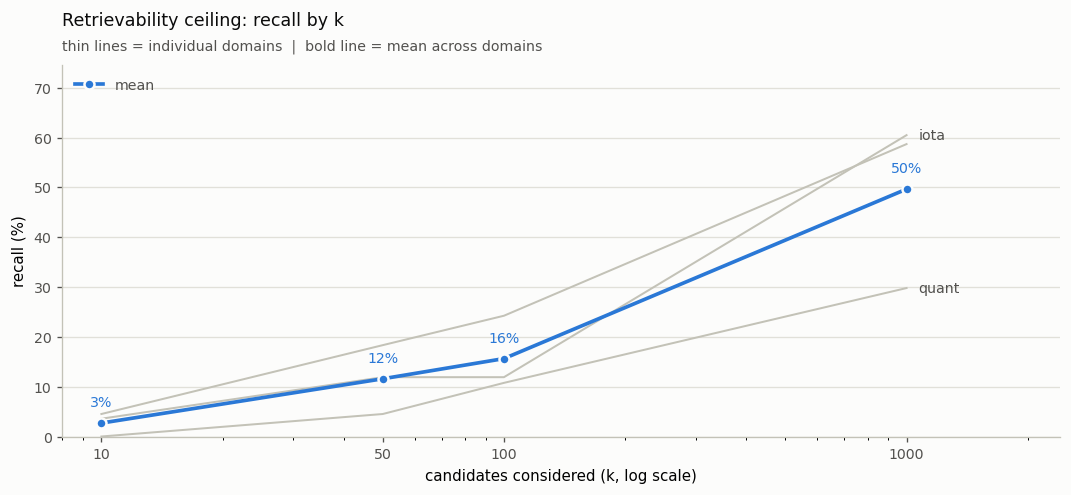

In [ ]:
cutoffs = [10, 50, 100, 1000]
fig, ax = new_axes(height=4.2, grid_axis="y")

for domain in RECALL_CEILING:
    ax.plot(cutoffs, [RECALL_CEILING[domain][k] * 100 for k in cutoffs],
            color=AXIS, linewidth=1.2, zorder=1)

# Label only the best and worst domain -- not every line.
if RECALL_CEILING:
    ordered = sorted(RECALL_CEILING, key=lambda d: RECALL_CEILING[d][1000])
    for domain in {ordered[0], ordered[-1]}:
        ax.annotate(domain, xy=(cutoffs[-1], RECALL_CEILING[domain][1000] * 100),
                    xytext=(7, 0), textcoords="offset points",
                    color=INK_MUTED, fontsize=8.5, va="center")

mean_recall = [sum(RECALL_CEILING[d][k] for d in RECALL_CEILING) / len(RECALL_CEILING) * 100
               for k in cutoffs]
ax.plot(cutoffs, mean_recall, color=PALETTE[0], linewidth=2.2, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3, label="mean")
for x, v in zip(cutoffs, mean_recall):
    ax.annotate(f"{v:.0f}%", (x, v), textcoords="offset points", xytext=(0, 10),
                ha="center", color=PALETTE[0], fontsize=8.5)

ax.set_xscale("log"); ax.set_xticks(cutoffs); ax.set_xticklabels([str(k) for k in cutoffs])
ax.set_xlabel("candidates considered (k, log scale)")
ax.set_ylabel("recall (%)")
ax.set_ylim(0, max(mean_recall + [10]) * 1.5); ax.set_xlim(8, cutoffs[-1] * 2.4)
ax.legend(frameon=False, loc="upper left", fontsize=8.5, labelcolor=INK_MUTED)
set_title(ax, "Retrievability ceiling: recall by k",
          "thin lines = individual domains  |  bold line = mean across domains")
plt.tight_layout(); plt.show()


### Quyết định · Decision — phần này định lại thứ tự ưu tiên · this re-orders the priorities

**VI** — Đọc theo thứ tự sau:

1. **So sánh R@100 với R@1000.** Nếu R@1000 cao hơn nhiều lần, tài liệu gold *có* được tìm thấy nhưng nằm sâu. Đây là tình huống thuận lợi: nâng số lượng ứng viên đưa vào tầng hai là cải tiến rẻ, có tác dụng ngay, không cần đổi mô hình.
2. **Xem cột `no gold @1000`.** Đây là những truy vấn mà tầng một thất bại hoàn toàn. Không kỹ thuật xếp hạng lại nào cứu được chúng.
3. **Đối chiếu R@100 với mục tiêu.** Nếu R@100 thấp, nút thắt nằm ở recall của tầng một chứ không ở chất lượng sắp xếp của tầng hai. Đầu tư vào bộ xếp hạng lại lúc đó là tối ưu nhầm chỗ.

Thứ tự đầu tư suy ra từ bảng này: nâng số lượng ứng viên nếu R@1000 ≫ R@100 → làm sạch truy vấn và gộp trùng lặp → nâng cấp mô hình biểu diễn → chỉ sau đó mới quay lại tầng xếp hạng lại.

**EN** — Read it in this order:

1. **Compare R@100 against R@1000.** If R@1000 is several times higher, gold documents *are* being found but ranked deep. That is the favourable case: raising the candidate count passed to stage two is cheap, immediately effective, and needs no model change.
2. **Check `no gold @1000`.** These are queries where the first stage failed outright. No reranking technique can rescue them.
3. **Compare R@100 against your target.** If R@100 is low, the bottleneck is first-stage recall, not second-stage ordering. Investing in a reranker then optimises the wrong thing.

Investment order implied: raise the candidate count if R@1000 ≫ R@100 → clean queries and merge duplicates → upgrade the representation model → only then return to reranking.

**VI — Cần làm thêm.** Bảng này đo trần của BM25. Hãy chạy lại phép đo tương tự với bộ truy hồi ngữ nghĩa mà hệ thống thực sự dùng — đó mới là trần thật của pipeline.
**EN — Follow-up.** This measures the BM25 ceiling. Repeat it with the semantic retriever the system actually uses — that is the pipeline's real ceiling.

## D2. Phép thử dạng truy vấn · Query-form ablation

**VI — Mục đích.** Trả lời bằng số liệu hai câu hỏi mà phần B1 đặt ra: làm sạch thẻ đánh dấu có tác dụng không, và thân bài đóng góp hay gây nhiễu.

**EN — Purpose.** Answer with data the two questions raised in Part B1: does stripping markup help, and does the post body contribute or interfere?

| Biến thể · Variant | Nội dung · Content |
| --- | --- |
| `raw` | Truy vấn giữ nguyên · Query as-is |
| `markup stripped` | Gỡ thẻ, giải mã thực thể HTML, gom khoảng trắng · Tags removed, HTML entities decoded, whitespace collapsed |
| `title only` | Chỉ phần tiêu đề, đã làm sạch · The title alone, cleaned |
| `title x3 + body` | Tiêu đề lặp ba lần đặt trước toàn bộ truy vấn · The title repeated three times ahead of the full query |

**VI — Đo bằng recall chứ không bằng nDCG**, vì mục tiêu ở đây là xác định dạng truy vấn nào đưa được nhiều tài liệu gold vào tập ứng viên nhất; thứ tự bên trong tập ứng viên là việc của tầng sau.

**EN — Measured by recall, not nDCG**, because the goal here is which query form puts the most gold documents into the candidate set; ordering within that set is the next stage's job.

In [ ]:
def strip_markup(text):
    text = re.sub(r"<[^>]+>", " ", text)
    text = ENTITY.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()

QUERY_VARIANTS = {
    "raw":              lambda q: q,
    "markup stripped":  strip_markup,
    "title only":       lambda q: strip_markup(split_title(q)[0]),
    "title x3 + body":  lambda q: strip_markup((split_title(q)[0] + " ") * 3 + q),
}
VARIANT_RESULTS = {}

print(f"{'domain':<10}{'variant':<18}{'R@100':>9}{'R@1000':>10}")
print("-" * 47)
for domain in HEAVY_SUBSET:
    corpus = list(stream_docs(domain))
    queries = load_queries(domain)
    bm25 = BM25([i for i, _ in corpus], [t for _, t in corpus])
    for name, transform in QUERY_VARIANTS.items():
        r100, r1000 = [], []
        for e in queries:
            gold = set(e["gold_ids"])
            ranked = [d for d, _ in bm25.search(transform(e["query"]), 1000)]
            r100.append(len(gold & set(ranked[:100])) / max(len(gold), 1))
            r1000.append(len(gold & set(ranked)) / max(len(gold), 1))
        VARIANT_RESULTS[(domain, name)] = (sum(r100)/len(r100)*100, sum(r1000)/len(r1000)*100)
        print(f"{domain:<10}{name:<18}{VARIANT_RESULTS[(domain,name)][0]:>8.1f}%"
              f"{VARIANT_RESULTS[(domain,name)][1]:>9.1f}%")
    print()
    del corpus, bm25


domain    variant               R@100    R@1000
-----------------------------------------------
iota      raw                   11.9%     60.5%
iota      markup stripped       11.9%     60.5%
iota      title only            26.4%     57.6%
iota      title x3 + body       12.9%     65.2%

law       raw                   24.2%     58.7%
law       markup stripped       27.3%     61.2%
law       title only            43.9%     65.4%
law       title x3 + body       39.8%     67.3%

quant     raw                   10.8%     29.8%
quant     markup stripped       12.2%     33.8%
quant     title only            33.5%     65.8%
quant     title x3 + body       13.7%     45.7%



### Biểu đồ · Chart — so sánh dạng truy vấn · query-form comparison

**VI** — Biến thể nào cao hơn nhất quán trên mọi domain mới được coi là thắng. Nếu thứ tự đảo giữa các domain thì chênh lệch nằm trong vùng nhiễu và cần đọc phần E trước khi kết luận.

**EN** — A variant only wins if it leads consistently across every domain. If the ordering flips between domains, the gap is within noise and Part E must be read before concluding.

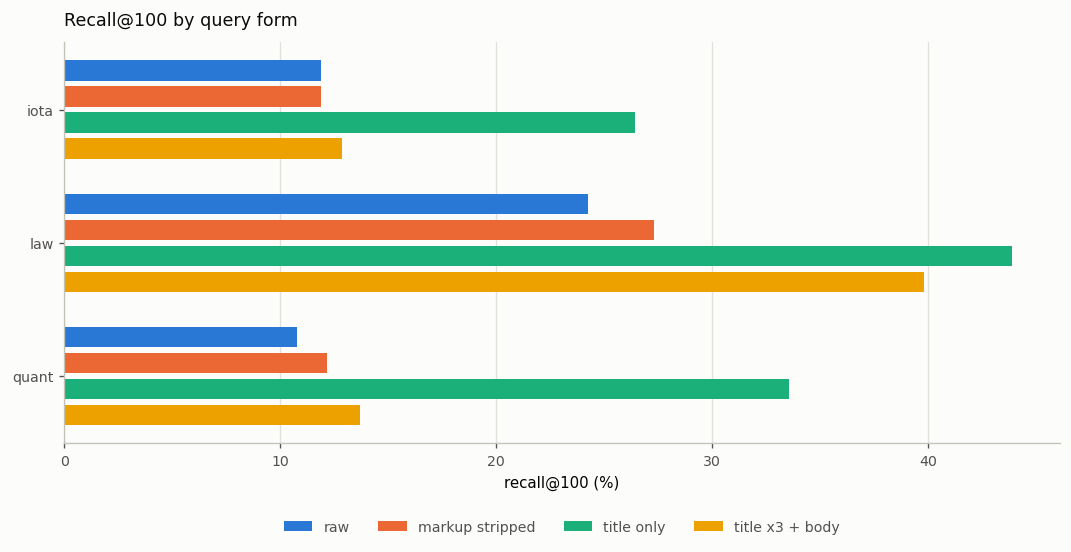

In [ ]:
domains_shown = sorted({d for d, _ in VARIANT_RESULTS})
variants = list(QUERY_VARIANTS)
n_var = len(variants)

fig, ax = new_axes(height=0.42 * len(domains_shown) * n_var / 2 + 2.2, grid_axis="x")
bar_h = 0.78 / n_var
for j, variant in enumerate(variants):
    y = [i + (j - (n_var - 1) / 2) * bar_h for i in range(len(domains_shown))]
    ax.barh(y, [VARIANT_RESULTS[(d, variant)][0] for d in domains_shown],
            height=bar_h * 0.78, color=PALETTE[j], label=variant)

ax.set_yticks(range(len(domains_shown))); ax.set_yticklabels(domains_shown)
ax.set_xlabel("recall@100 (%)"); ax.invert_yaxis()
ax.legend(frameon=False, ncol=n_var, fontsize=8.5, labelcolor=INK_MUTED,
          loc="upper center", bbox_to_anchor=(0.5, -0.16))
set_title(ax, "Recall@100 by query form")
plt.tight_layout(); plt.show()


### Quyết định · Decision

**VI** — Áp dụng biến thể thắng nhất quán, và áp dụng cho **cả** tầng khớp từ khoá lẫn tầng ngữ nghĩa.

- **`markup stripped` thắng** → cải tiến gần như miễn phí, áp dụng ngay.
- **`title only` thắng** → thân bài chủ yếu là nhiễu. Kết luận đáng đưa vào báo cáo, và mở ra hướng tách riêng vai trò của tiêu đề và bối cảnh.
- **`title x3 + body` thắng** → thân bài có đóng góp nhưng cần giảm trọng số, không nên bỏ hẳn.
- **Không biến thể nào thắng nhất quán** → chênh lệch nằm trong vùng nhiễu; đọc phần E trước khi chọn.

**EN** — Adopt the consistently winning variant, and apply it to **both** the lexical and the semantic stage.

- **`markup stripped` wins** → a near-free improvement; apply it immediately.
- **`title only` wins** → the body is mostly noise. Worth reporting, and it opens the door to treating title and context separately.
- **`title x3 + body` wins** → the body contributes but needs down-weighting rather than removal.
- **No consistent winner** → the differences are within noise; read Part E before choosing.

**VI — Cảnh báo.** Phép thử này đo trên một bộ truy hồi từ khoá và một số domain giới hạn. Xác nhận lại với bộ truy hồi ngữ nghĩa trên đầy đủ domain trước khi đưa vào hệ thống.
**EN — Caveat.** This measures one lexical retriever over a limited set of domains. Confirm with the semantic retriever across all domains before shipping it.

# Phần E — Độ tin cậy thống kê
# Part E — Statistical reliability

**VI — Mục đích.** Thiết lập ngưỡng để phân biệt cải tiến thật với dao động ngẫu nhiên.

**VI — Vấn đề.** Chỉ số nDCG@10 trên từng truy vấn có phân bố lệch mạnh: phần lớn truy vấn được điểm rất thấp hoặc bằng 0, một số ít được điểm cao. Trung bình của một đại lượng như vậy trên mẫu nhỏ dao động rất mạnh. Trên một domain vài chục truy vấn, hai phương pháp có thể chênh nhau đáng kể mà không phản ánh khác biệt nào về năng lực.

**EN — Purpose.** Establish the threshold that separates a real improvement from random fluctuation.

**EN — The problem.** Per-query nDCG@10 is heavily skewed: most queries score very low or zero, a few score high. The mean of such a quantity is volatile on small samples. On a domain of a few dozen queries, two methods can differ substantially without reflecting any difference in capability.

**VI — Cách đo.** Lấy mẫu lặp lại (bootstrap) trên phân bố điểm từng truy vấn, tính khoảng tin cậy 95% cho trung bình, ứng với các cỡ mẫu có thật trong bộ dữ liệu.

**EN — Method.** Bootstrap resampling over the per-query score distribution, giving a 95% confidence interval for the mean at the sample sizes that actually occur in this dataset.

**VI — Tham số `mean_score`.** Mặc định 0,2, xấp xỉ mức của một hệ thống chưa tối ưu trên bài toán này. Thay bằng giá trị thật của hệ thống bạn khi đã có kết quả để có ngưỡng chính xác hơn.
**EN — The `mean_score` parameter.** Defaults to 0.2, roughly the level of an untuned system on this task. Substitute your own system's measured value once you have it, for a sharper threshold.

In [ ]:
random.seed(0)

def ci_halfwidth(n_queries, mean_score=0.2, n_resamples=2000):
    """Half-width of the 95% CI for mean nDCG over n_queries.

    Models the bimodal per-query distribution this task produces: a query
    either scores well or scores nothing, rather than clustering on the mean.
    """
    pool = [1.0] * int(n_queries * mean_score) + [0.0] * (n_queries - int(n_queries * mean_score))
    means = sorted(sum(random.choice(pool) for _ in range(n_queries)) / n_queries
                   for _ in range(n_resamples))
    return (means[int(.975 * n_resamples)] - means[int(.025 * n_resamples)]) / 2

sizes = sorted((len(load_queries(d)), d) for d in DOMAINS)
sample_sizes = [
    (f"{sizes[0][1]} (smallest domain)",          sizes[0][0]),
    (f"{sizes[len(sizes)//2][1]} (median domain)", sizes[len(sizes)//2][0]),
    (f"{sizes[-1][1]} (largest domain)",           sizes[-1][0]),
    ("all train queries pooled",                   sum(s for s, _ in sizes)),
]

print(f"{'scope':<36}{'N':>7}{'95% CI':>11}{'smallest real gap':>21}")
print("-" * 76)
for label, n in sample_sizes:
    half = ci_halfwidth(n)
    print(f"{label:<36}{n:>7}{half:>10.3f}{2*half:>20.3f}")


scope                                     N     95% CI    smallest real gap
----------------------------------------------------------------------------
iota (smallest domain)                    7     0.214               0.429
economics (median domain)                58     0.103               0.207
history (largest domain)                561     0.034               0.068
all train queries pooled               1211     0.022               0.045


### Biểu đồ · Chart — ngưỡng theo cỡ mẫu · threshold by sample size

**VI** — Trục ngang là số truy vấn dùng để đánh giá, trục dọc là chênh lệch nhỏ nhất giữa hai phương pháp mà vẫn phân biệt được với nhiễu. Các điểm được đánh dấu là cỡ mẫu có thật trong bộ dữ liệu. Đường cong giảm theo căn bậc hai của cỡ mẫu — đó là lý do chỉ có đánh giá gộp toàn bộ mới cho phép kết luận về những cải tiến vài điểm phần trăm.

**EN** — The x-axis is the number of queries used for evaluation; the y-axis is the smallest difference between two methods that remains distinguishable from noise. The marked points are the sample sizes that actually occur here. The curve falls with the square root of sample size — which is why only a pooled evaluation supports conclusions about improvements of a few percentage points.

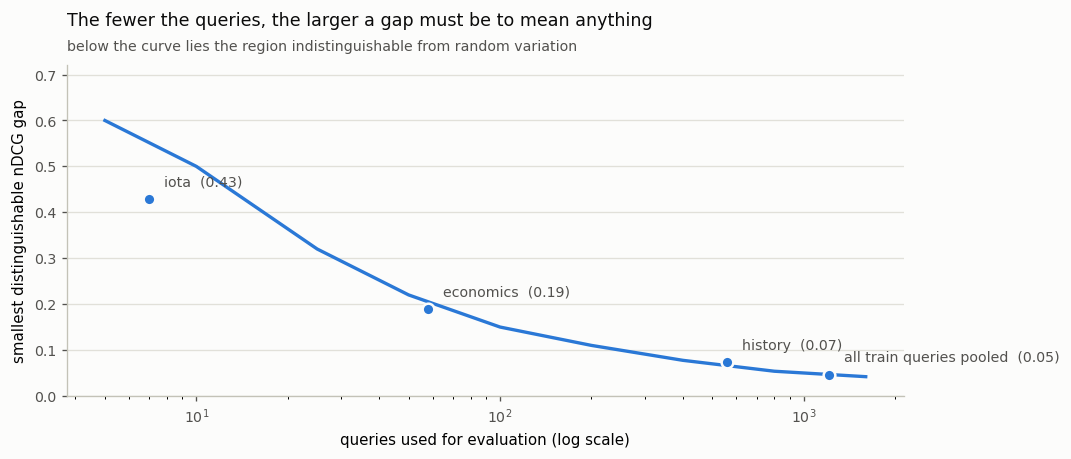

In [ ]:
grid_n = [5, 10, 25, 50, 100, 200, 400, 800, 1600]
thresholds = [2 * ci_halfwidth(n, n_resamples=600) for n in grid_n]

fig, ax = new_axes(height=3.9, grid_axis="y")
ax.plot(grid_n, thresholds, color=PALETTE[0], linewidth=2)

# Group labels that share a sample size so they never overlap.
grouped = {}
for label, n in sample_sizes:
    grouped.setdefault(n, []).append(label.split(" (")[0])
for n, labels in sorted(grouped.items()):
    gap = 2 * ci_halfwidth(n, n_resamples=600)
    ax.plot([n], [gap], "o", color=PALETTE[0], markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)
    ax.annotate(f"{' / '.join(labels)}  ({gap:.2f})", (n, gap),
                textcoords="offset points", xytext=(9, 8),
                color=INK_MUTED, fontsize=8.5)

ax.set_xscale("log")
ax.set_xlabel("queries used for evaluation (log scale)")
ax.set_ylabel("smallest distinguishable nDCG gap")
ax.set_ylim(0, max(thresholds) * 1.2)
set_title(ax, "The fewer the queries, the larger a gap must be to mean anything",
          "below the curve lies the region indistinguishable from random variation")
plt.tight_layout(); plt.show()


### Quyết định · Decision — quy tắc làm việc, không phải một con số · a working rule, not a number

**VI**
1. **Không kết luận từ một domain đơn lẻ.** Cột `smallest real gap` cho biết khoảng cách nhỏ nhất giữa hai phương pháp mà vẫn phân biệt được với nhiễu. Trên các domain nhỏ, ngưỡng này lớn hơn phần lớn cải tiến kỹ thuật thực tế, nghĩa là mọi so sánh ở quy mô đó đều không kết luận được.
2. **Luôn báo cáo trung bình macro trên toàn bộ domain.** Chỉ ở quy mô gộp, ngưỡng mới đủ nhỏ để một chênh lệch vài điểm phần trăm mang ý nghĩa.
3. **Khi hai phương án cách nhau dưới ngưỡng, không chọn theo điểm số.** Chọn cái đơn giản hơn, rẻ hơn về tính toán, hoặc có cơ chế giải thích rõ ràng hơn.
4. **Bằng chứng cơ chế đáng tin hơn chênh lệch điểm trên mẫu nhỏ.** Một kết luận dạng "A hơn B vì recall của A cao hơn ở tầng một" vững hơn nhiều so với "A hơn B 0,03 điểm trên một domain".

**EN**
1. **Never conclude from a single domain.** The `smallest real gap` column gives the minimum separation that stays distinguishable from noise. On small domains that threshold exceeds most real technical improvements, so any comparison at that scale is inconclusive.
2. **Always report the macro average across all domains.** Only at the pooled scale is the threshold small enough for a few-percentage-point difference to mean anything.
3. **When two options are closer than the threshold, do not pick by score.** Pick the one that is simpler, cheaper to compute, or has a clearer mechanistic explanation.
4. **Mechanistic evidence beats a score gap on a small sample.** A conclusion of the form "A beats B because A's first-stage recall is higher" is far more solid than "A beats B by 0.03 on one domain".

**VI** — Ngưỡng này nên được ghi kèm mọi bảng kết quả trong báo cáo.
**EN** — Report this threshold alongside every results table.

# Phần F — Cấu trúc mã định danh tài liệu
# Part F — Document identifier structure

**VI — Mục đích.** Kiểm tra xem mã định danh tài liệu có mang thông tin về nhãn hay không. Đây là bước kiểm toán tiêu chuẩn với mọi bộ dữ liệu được lắp ghép từ nhiều nguồn: quy trình xây dựng đôi khi để lại dấu vết trong cách đặt tên, và dấu vết đó có thể tương quan với nhãn mà không mang ý nghĩa ngữ nghĩa nào.

**EN — Purpose.** Check whether document identifiers carry information about the labels. This is a standard audit for any dataset assembled from multiple sources: the construction process sometimes leaves traces in the naming, and those traces can correlate with the labels while carrying no semantic meaning.

**VI — Đo gì.**
- **Dạng mã định danh.** Quy mọi mã về một khuôn trừu tượng, trong đó `N` là cụm chữ số và `H<k>` là cụm không phải chữ số dài `k` ký tự. Đối chiếu phân bố dạng trên toàn corpus với phân bố dạng trên riêng tập gold.
- **Mức thu hẹp vùng tìm kiếm.** Nếu tài liệu gold chỉ thuộc một số dạng nhất định, tỷ số giữa kích thước corpus và kích thước vùng mang dạng đó cho biết vùng tìm kiếm bị thu hẹp bao nhiêu lần chỉ nhờ nhìn tên file.
- **Tính liên tiếp.** Với mã kết thúc bằng chỉ số, kiểm tra xem tập gold của một truy vấn có tạo thành dãy chỉ số liên tiếp hay không.

**EN — Measured.**
- **Identifier shape.** Reduce each identifier to an abstract pattern where `N` is a run of digits and `H<k>` a non-digit run of length `k`. Compare the shape distribution over the whole corpus against the shapes seen among gold documents only.
- **Search-space reduction.** If gold documents occupy only certain shapes, the ratio of corpus size to the size of that region shows how far the search space narrows from filename alone.
- **Contiguity.** For identifiers ending in an index, test whether a query's gold set forms a contiguous run.

In [ ]:
def id_shape(doc_id):
    stem = doc_id.split("/")[-1][:-4]
    return "_".join(("N" if part.isdigit() else f"H{len(part)}") for part in stem.split("_"))

print(f"{'domain':<14}{'corpus':>9}{'gold':>6}{'gold shape(s)':>24}"
      f"{'reduction':>11}{'contiguous':>12}")
print("-" * 78)
for domain in DOMAINS:
    queries = load_queries(domain, "train") + load_queries(domain, "dev")
    gold = {g for e in queries for g in e["gold_ids"]}
    corpus_shapes = Counter(id_shape(i) for i, _ in stream_docs(domain))
    gold_shapes   = Counter(id_shape(g) for g in gold)
    region = sum(v for shape, v in corpus_shapes.items() if shape in gold_shapes)
    n = sum(corpus_shapes.values())

    contiguous = []
    for e in queries:
        tails = [g.split("_")[-1][:-4] for g in e["gold_ids"]]
        if len(tails) > 1 and all(t.isdigit() for t in tails):
            nums = sorted(int(t) for t in tails)
            contiguous.append(nums[-1] - nums[0] + 1 == len(nums))

    summary = ", ".join(f"{s}:{v}" for s, v in gold_shapes.most_common(2))
    print(f"{domain:<14}{n:>9,}{len(gold):>6}{summary:>24}{n/max(region,1):>10.1f}x"
          f"{sum(contiguous):>8}/{len(contiguous):<4}")


domain           corpus  gold           gold shape(s)  reduction  contiguous
------------------------------------------------------------------------------
bitcoin         153,291   327         H8_N:318, N_N:9       4.9x      84/84  
cardano          87,201   125         H8_N:123, N_N:2       6.3x      39/39  
economics        93,756   299         H8_N:295, N_N:4       3.5x      73/73  
genealogy       156,228   327         H8_N:318, N_N:9       8.8x      94/94  
history         356,493  3573       H8_N:3483, N_N:90       1.0x     729/729 
hsm             213,818   368         H8_N:363, N_N:5       7.5x     128/128 
iota             10,372    38                 H8_N:38       4.4x      10/10  
law              43,288   106         H8_N:105, N_N:1       3.8x      25/25  
monero           85,093   169         H8_N:164, N_N:5       4.7x      54/54  
politics        183,394   408        H8_N:395, N_N:13       5.2x     139/139 
quant            28,785    83          H8_N:81, N_N:2       4.2x

### Quyết định · Decision

**VI — Nếu tài liệu gold phân bố đều trên các dạng mã định danh và tỷ lệ liên tiếp thấp** → mã định danh không mang thông tin về nhãn. Ghi nhận kết quả kiểm toán và chuyển sang phần khác.

**VI — Nếu tài liệu gold tập trung vào một dạng, hoặc tập gold có tính liên tiếp cao** → mã định danh mang thông tin tương quan với nhãn. Xử lý như sau:

1. **Không đưa đặc trưng này vào hệ thống dự thi.** Nó phản ánh quy trình xây dựng dữ liệu chứ không phản ánh quan hệ ngữ nghĩa giữa truy vấn và tài liệu. Hệ thống dựa vào nó không chứng minh được năng lực truy hồi, và sẽ sụp đổ nếu ban tổ chức đánh lại mã định danh hoặc nếu đặc điểm này không tồn tại trên tập kiểm tra ẩn.
2. **Báo cho ban tổ chức.** Thông tin liên hệ có trong tài liệu mô tả bộ dữ liệu. Phát hiện và báo cáo sớm một rò rỉ nhãn là đóng góp có giá trị cho chất lượng của benchmark.
3. **Dùng làm thước đo đối chiếu trong báo cáo.** Đo điểm của một hệ thống khai thác triệt để đặc điểm này rồi so với hệ thống hợp lệ. Chênh lệch cho biết bao nhiêu phần dư địa của bộ dữ liệu đến từ dấu vết quy trình chứ không từ bài toán thật. Phân tích này trung thực vì nó nêu rõ bản chất của con số.
4. **Kiểm tra lại mọi mô hình được huấn luyện trên dữ liệu này.** Mô hình không đọc tên file, nhưng có thể bám vào các đặc trưng bề mặt tương quan với quy trình xây dựng. Rủi ro này không tồn tại với mô hình dùng nguyên trạng, nhưng cần kiểm tra nếu có bước tinh chỉnh.

**EN — If gold documents spread evenly across identifier shapes and contiguity is low** → identifiers carry no label information. Record the audit result and move on.

**EN — If gold documents concentrate in one shape, or gold sets are highly contiguous** → identifiers carry label-correlated information. Handle it as follows:

1. **Do not put this feature in the competition system.** It reflects the data construction process, not a semantic relationship between query and document. A system relying on it demonstrates no retrieval capability, and collapses if the organisers re-issue the identifiers or if the property is absent from the hidden test set.
2. **Report it to the organisers.** Contact details are in the dataset documentation. Finding and reporting a label leak early is a genuine contribution to the benchmark's quality.
3. **Use it as a reference measurement in the report.** Score a system that exploits the property fully, and compare against the legitimate system. The gap shows how much of the dataset's headroom comes from a process artefact rather than from the actual task. The analysis is honest because it states plainly what the number is.
4. **Re-examine any model trained on this data.** A model does not read filenames, but it can latch onto surface features correlated with the construction process. The risk is absent for off-the-shelf models, but must be checked if any fine-tuning is involved.

# Phần G — Tổng kết quyết định
# Part G — Decision summary

**VI** — Bảng dưới đây ghi kết quả chạy trên **đủ 13 domain Track 1** (1.654.055 tài liệu, 1.211 truy vấn train). Phần D chỉ chạy trên ba domain nhỏ vì chi phí dựng chỉ mục, và được đánh dấu rõ.

**EN** — The table below records a run over **all 13 Track 1 domains** (1,654,055 documents, 1,211 train queries). Part D covers only the three small domains because of indexing cost, and is marked accordingly.

| Phần · Part | Nội dung đo · Measurement | Số liệu · Observed | Quyết định · Decision |
| --- | --- | --- | --- |
| A1 | Toàn vẹn dữ liệu · Data integrity | 0 ở cả năm cột, 13/13 domain · zero in all five columns, 13/13 domains | Dữ liệu sạch; đọc mọi phân tích sau ở nguyên giá trị · Data is intact; later analyses read at face value |
| A2 | Trùng lặp corpus · Corpus duplicates | Trung vị **20,7%**, cao nhất `bitcoin` **50,0%**, thấp nhất `iota` 6,7% — **13/13 domain vượt ngưỡng 2%** · median 20.7%, max 50.0%, min 6.7% — all 13 above the 2% threshold | **Bắt buộc gộp trùng lặp trước khi đánh index.** Một nửa corpus `bitcoin` là bản sao · **Merge duplicates before indexing.** Half the `bitcoin` corpus is copies |
| A2 | Đuôi độ dài tài liệu · Length tail | Trung vị 104–163 từ; p99 từ 1.271 đến 28.271 · median 104–163 words; p99 from 1,271 to 28,271 | Đuôi nặng nhưng thưa; quyết định cắt hay chia đoạn theo C3 chứ không theo cột này · Heavy but sparse tail; let C3, not this column, decide truncation vs chunking |
| A2 | Rác và HTML trong tài liệu · Junk and HTML in documents | Rác ≤ 0,4%; HTML ≤ 0,1% · junk ≤ 0.4%; HTML ≤ 0.1% | Không cần bước lọc rác. Ghi nhận: tài liệu **không** chứa thẻ đánh dấu · No junk filter needed. Note: documents carry **no** markup |
| A3 | Trùng lặp giữa domain · Cross-domain overlap | 9–29 tài liệu chung, 0,1–0,2% · 9–29 shared documents, 0.1–0.2% | Các domain độc lập trên thực tế; trung bình macro đọc được bình thường · Domains are effectively disjoint; the macro average reads normally |
| B1 | Thẻ đánh dấu trong truy vấn · Markup in queries | **100% truy vấn chứa thẻ HTML, 13/13 domain**; thực thể HTML tới 50,5% ở `politics` · 100% of queries carry HTML tags in every domain; entities up to 50.5% | Lệch pha hoàn toàn so với phía tài liệu (0,1%) → thêm bước làm sạch truy vấn · A total mismatch against the document side (0.1%) → add a query-cleaning step |
| B1 | Tỷ lệ tiêu đề / thân bài · Title-to-body ratio | 4,8x–18,0x, trung vị khoảng 10x · 4.8x–18.0x, median around 10x | Truy vấn bị thân bài chi phối → đo dạng truy vấn ở D2 trước khi chốt · The body dominates the query → measure query forms in D2 before committing |
| B2 | Dấu hiệu thời gian · Temporal markers | 72,9% có ít nhất một dấu hiệu; `before/after` 31,7%, `explicit year` 24,4%, `since/until` 19,3%, `now/today` 19,2% | Hỗn hợp mốc tuyệt đối và tương đối, không nhóm nào áp đảo → để C4 quyết · A mix of absolute and relative markers with no clear majority → let C4 decide |
| C1 | Chồng lấn từ vựng · Lexical overlap | Trung vị **31,0%**; **6/13 domain dưới 30%**; `quant` 17,0%, `travel` 21,3%; cao nhất `iota` 48,3% | Khớp từ khoá gần hết dư địa. **Ngừng tinh chỉnh k1/b**; dồn nguồn lực vào biểu diễn ngữ nghĩa · Lexical matching is near its ceiling. **Stop tuning k1/b**; invest in semantic representation |
| C2 | Gold bị nhân bản · Duplicated gold | **5/13 domain ≥ 3%**: `monero` 27,0%, `quant` 14,8%, `bitcoin` 12,1%, `travel` 9,5%, `iota` 6,9%. `history` 2,4% nhưng có 185 bản sao mồi | Xử lý bằng bảng băm nội dung cho năm domain đó · Handle those five with a content-hash map |
| C3 | Vị trí bằng chứng · Evidence position | **5/13 domain vượt 30%**: `politics` 67,8%, `hsm` 66,7%, `iota` 37,9%, `workplace` 32,9%, `genealogy` 31,8%. Nhưng **7/13 dưới 10%**, trong đó bốn domain bằng 0% | **Xử lý theo domain, không áp dụng chung.** Chia đoạn hoặc nâng ngưỡng cắt cho nhóm có tài liệu gold dài; giữ nguyên cho nhóm còn lại · **Handle per domain, not globally.** Chunk or raise the limit where gold documents are long; leave the rest alone |
| C4 | Ăn khớp năm · Year alignment | Gộp: **109/296 = 36,8%** truy vấn có năm cũng thấy năm đó trong tập gold. `politics` 45/68, `economics` 16/27, `workplace` 1/2 đạt ≥ 50%; `cardano`, `law`, `quant` bằng 0 | **Không loại bỏ hoàn toàn.** Tín hiệu có thật ở một số domain nhưng vắng hẳn ở domain khác → nếu xây, phải xây có điều kiện và đo riêng từng domain · **Do not discard outright.** The signal is real in some domains and absent in others → if built, make it conditional and measure per domain |
| D1 | Trần recall · Recall ceiling | *Ba domain nhỏ:* R@100 10,8–24,2%; R@1000 29,8–60,5%. `quant` có 13/24 truy vấn không có gold nào trong top 1000 · *Three small domains:* R@100 10.8–24.2%; R@1000 29.8–60.5% | Nút thắt nằm ở recall tầng một → nâng số lượng ứng viên. **Cần chạy lại trên đủ 13 domain và với bộ truy hồi ngữ nghĩa** · The bottleneck is first-stage recall → raise the candidate count. **Must be re-run over all 13 domains and with the semantic retriever** |
| D2 | Dạng truy vấn tốt nhất · Best query form | *Ba domain nhỏ:* `title only` thắng R@100 ở cả ba — 26,4% / 43,9% / 33,5% so với 11,9% / 24,2% / 10,8% của truy vấn nguyên bản. Chỉ gỡ thẻ HTML gần như không đổi · *Three small domains:* `title only` wins R@100 in all three; stripping markup alone barely moves it | Áp dụng dạng chỉ tiêu đề, **nhưng xác nhận trên đủ 13 domain trước khi chốt** · Adopt the title-only form, **but confirm across all 13 domains first** |
| E | Ngưỡng chênh lệch tối thiểu · Minimum detectable gap | 7 câu hỏi: **0,429** · 58 câu: **0,207** · 561 câu: **0,068** · gộp 1.211 câu: **0,045** | Chỉ kết luận ở mức gộp toàn bộ. Mọi so sánh trên một domain đơn lẻ đều không đủ căn cứ · Conclude only at the pooled level. Any single-domain comparison is inconclusive |
| F | Cấu trúc mã định danh · Identifier structure | Tài liệu gold tập trung vào dạng `H8_N` ở **13/13 domain**; vùng tìm kiếm thu hẹp 1,0x–8,8x; tập gold liên tiếp **1.516/1.516 = 100%** | **Không đưa vào hệ thống dự thi.** Báo cho ban tổ chức. Dùng làm thước đo đối chiếu trong báo cáo · **Keep it out of the competition system.** Report it to the organisers. Use it as a reference measurement in the report |

---

## Ba kết luận bị lật ngược khi mở rộng từ 3 lên 13 domain
## Three conclusions reversed when going from 3 to 13 domains

**VI** — Ghi lại ở đây vì đây là bài học phương pháp quan trọng hơn bất kỳ con số đơn lẻ nào trong bảng trên.

**EN** — Recorded here because the methodological lesson matters more than any single number above.

| Kết luận từ 3 domain nhỏ · From the three small domains | Thực tế trên 13 domain · What all 13 show |
| --- | --- |
| Trùng lặp corpus 6,7–16,6%, đáng xử lý nhưng không nghiêm trọng · Duplicates 6.7–16.6%, worth handling but not severe | Trung vị 20,7%, `bitcoin` tới **50,0%** — nghiêm trọng hơn nhiều · Median 20.7%, up to 50.0% — far more severe |
| Chia đoạn tài liệu không cần thiết (2/3 domain có 0% vượt ngân sách) · Chunking unnecessary (two of three domains at 0%) | **5/13 domain vượt 30%**, `politics` và `hsm` tới hai phần ba · Five of 13 exceed 30%, two of them at two-thirds |
| Khớp năm theo chuỗi hoàn toàn vô dụng (0/7 và 0/8) · String matching on years entirely useless (0/7 and 0/8) | **36,8% tổng thể**, và chiếm đa số ở `politics`, `economics` · 36.8% overall, and a majority in `politics` and `economics` |

**VI** — Cả ba lần, mẫu nhỏ không chỉ kém chính xác mà còn **chỉ sai hướng**. Phần E đã cảnh báo điều này bằng con số: ở cỡ mẫu vài chục truy vấn, ngưỡng nhiễu lớn hơn phần lớn hiệu ứng thật. Nguyên tắc rút ra: mẫu nhỏ dùng để **kiểm tra pipeline chạy được**, không dùng để **kết luận về dữ liệu**.

**EN** — In all three cases the small sample was not merely imprecise but **pointed the wrong way**. Part E warned of exactly this: at a few dozen queries the noise threshold exceeds most real effects. The rule: use small samples to **check that the pipeline runs**, never to **draw conclusions about the data**.

---

## Thứ tự công việc · Work order

**VI** — Sắp theo tỷ lệ lợi ích trên chi phí, dựa trên số liệu ở bảng trên.

**EN** — Ordered by benefit against cost, based on the figures above.

| # | Việc · Action | Căn cứ · Evidence |
| --- | --- | --- |
| 1 | Gộp tài liệu trùng lặp trước khi đánh index · Merge duplicate documents before indexing | 13/13 domain vượt ngưỡng; `bitcoin` 50,0% · all 13 domains above threshold |
| 2 | Chuyển sang dạng truy vấn chỉ tiêu đề, xác nhận trên 13 domain · Switch to the title-only query form, confirmed across 13 domains | R@100 tăng 2–3 lần trên cả ba domain đã đo · 2–3x recall@100 in all three measured |
| 3 | Nâng số lượng ứng viên đưa vào tầng sau · Raise the candidate count passed downstream | R@1000 cao gấp 2,5–5 lần R@100 · R@1000 is 2.5–5x R@100 |
| 4 | Xử lý bản sao của tài liệu gold ở 5 domain · Handle duplicated gold in the five affected domains | `monero` 27,0%, `quant` 14,8%, `bitcoin` 12,1% |
| 5 | Chuyển trọng tâm sang truy hồi ngữ nghĩa · Shift the weight to semantic retrieval | Chồng lấn từ vựng trung vị 31,0%, 6/13 domain dưới 30% · median lexical overlap 31.0% |
| 6 | Ngưỡng cắt thích ứng hoặc chia đoạn cho nhóm domain gold dài · Adaptive truncation or chunking for the long-gold domains | `politics` 67,8%, `hsm` 66,7% vượt ngân sách token |
| 7 | Chỉ thêm tầng xếp hạng lại sau khi recall đã cải thiện · Add reranking only after recall improves | Trần recall hiện tại chặn mọi thứ phía sau · the current recall ceiling caps everything downstream |

**VI** — Hai việc **không** làm: tinh chỉnh tham số BM25 (không còn dư địa), và xây module ngày tháng áp dụng chung cho mọi domain (tín hiệu chỉ có ở một phần).

**EN** — Two things **not** to do: tune BM25 parameters (no headroom left), and build a date module applied uniformly across domains (the signal exists in only some of them).

**VI** — Mọi so sánh ở mỗi bước đều phải kèm ngưỡng nhiễu từ phần E: **0,045 khi gộp toàn bộ 1.211 truy vấn**, và lớn hơn nhiều ở bất kỳ phạm vi nhỏ hơn nào.

**EN** — Every comparison at every step carries the noise threshold from Part E: **0.045 when pooling all 1,211 queries**, and considerably larger at any smaller scope.